# Graphs Creation

This notebook loads the SciCite JSON datasets, builds the corresponding graph structures, and enriches them with the Semantic Scholar API.

## Table of contents

1. [Load and inspect the JSON datasets](#1-load-and-inspect-the-json-datasets)
   - 1.1 [Load the JSONs](#11-load-the-jsons)
   - 1.2 [Check the most important statistics](#12-check-the-most-important-statistics)
   - 1.3 [Drop the Nones](#13-drop-the-nones)
   - 1.4 [Check for intersections between the sets](#14-check-for-intersections-between-the-sets)
2. [Build fully disjoint graph structures](#2-build-fully-disjoint-graph-structures)
   - 2.1 [Visualization](#21-visualization)
3. [Enrich the graphs with the Semantic Scholar API](#3-enrich-the-graphs-with-the-semantic-scholar-api)
   - 3.0 [Semantic Scholar API fetching utils](#30-semantic-scholar-api-fetching-utils)
   - 3.1 [One-hop graph expansion](#31-one-hop-graph-expansion)
   - 3.2 [Re-enforce disjointness after enrichment](#32-re-enforce-disjointness-after-enrichment)
   - 3.3 [Expanded (and disjointed) graph inspection](#33-expanded-and-disjointed-graph-inspection)
     - 3.3.1 [Graph statistics](#331-graph-statistics)
     - 3.3.2 [Deeper morphological view](#332-deeper-morphological-view)
     - 3.3.3 [Dive inside `dev`](#333-dive-inside-dev)
     - 3.3.4 [Another expansion of `dev` split](#334-another-expansion-of-dev-split)
     - 3.3.5 [Small checks and fixes](#335-small-checks-and-fixes)
   - 3.4 [Node feature enrichment (embeddings and metadata)](#34-node-feature-enrichment-embeddings-and-metadata)
     - 3.4.1 [Fetch node details](#341-fetch-node-details)
     - 3.4.2 [Enrich the graphs with the details](#342-enrich-the-graphs-with-the-details)
   - 3.5 [Post-enrichment analysis](#35-post-enrichment-analysis)
   - 3.6 [Handle missing embeddings](#36-handle-missing-embeddings)
   - 3.7 [Handling SCC (directed loops) that should not exist](#37-handling-scc-directed-loops-that-should-not-exist)
4. [Save the splits for further usages](#4-save-the-splits-for-further-usages)

## 1. Load and inspect the JSON datasets

### 1.1 Load the JSONs

In [2]:
import os
from pathlib import Path
import pandas as pd

ROOT = Path(".").resolve().parent
DATASET_DIR = ROOT / "scicite"
DOTENV = ROOT / ".env"

from dotenv import load_dotenv
load_dotenv(DOTENV)

original_datasets = {}
for filename in os.listdir(DATASET_DIR):
    if not filename.startswith(".") and not (DATASET_DIR / filename).is_dir():
        name = filename.split(".")[0]
        original_datasets[name] = pd.read_json(DATASET_DIR / filename, lines=True)


### 1.2 Check the most important statistics

In [3]:
tot_line = 120
for n, df in original_datasets.items():
    print("=" * tot_line)
    print(f" {n} ".center(tot_line, "="))
    print("=" * tot_line)

    print()
    print(f"Unique citing papers: {len(df['citingPaperId'].unique())}")
    print(f"Unique cited papers: {len(df['citedPaperId'].unique())}")
    print(f"Unique papers: {len(set(df['citedPaperId'].unique().tolist() + df['citingPaperId'].unique().tolist()))}")
    print(f"Label1 count: {df['label'].value_counts().to_dict()}")
    print(f"Label2 count: {df['label2'].value_counts().to_dict()}")
    print(f"Source count: {df['source'].value_counts().to_dict()}")
    print(f"citedPaperId counts: {df['citedPaperId'].value_counts().to_dict()}")
    print(f"citingPaperId counts: {df['citingPaperId'].value_counts().to_dict()}")

    display(df.describe())
    print(df.info())
    display(df.head(2))


======================================================== train =========================================================

Unique citing papers: 4664
Unique cited papers: 4557
Unique papers: 9221
Label1 count: {'background': 4840, 'method': 2294, 'result': 1109}
Label2 count: {'not_supportive': 471, 'supportive': 356, 'cant_determine': 8}
Source count: {'explicit': 7886, 'properNoun': 142, 'acronym': 131, 'acronymParen': 53, 'andPhrase': 19, 'etAlPhrase': 10}
citedPaperId counts: {'None': 106, '21096eb950bdff77308ad3924d69b681589bdc91': 17, 'd55c95cedf9904a2776b682518c24b4d4d96bec7': 17, 'fe13f843c52243e096d7e1a52345a68eaf2cfef1': 17, 'b0fe8d2727db77f58bc430fef29aba3308ecd3f2': 16, '8d588720ea1b676f8b3906b696e06cf64f5b766b': 16, '21aaceb3fc27e8cc831e25191d967daa0d8962bf': 15, '61ba484c3fd142d5ddf606eae1a549fe29594208': 15, '60ed4bdabf92b2fbd6162dbd8979888cccca55d7': 15, 'eb08d5a6852228a7b45deb22f1bf4dde945020c6': 14, 'efe167e81022b9fb2b41ea7de996515c26f94838': 14, '5af4e6e8d6e7a25cb37a9

,citeEnd,citeStart,label_confidence,excerpt_index,label2_confidence
count,8241.000000,8241.000000,6137.000000,8243.000000,317.000000
mean,163.965781,139.709744,0.876606,2.333495,0.741582
std,121.478095,79.479383,0.144244,3.326236,0.191581
min,3.000000,0.000000,0.600000,0.000000,0.249800
25%,103.000000,87.000000,0.744700,0.000000,0.616900
50%,152.000000,134.000000,1.000000,1.000000,0.738500
75%,208.000000,187.000000,1.000000,3.000000,1.000000
max,3305.000000,1184.000000,1.000000,19.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 8243 entries, 0 to 8242
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   source             8241 non-null   str    
 1   citeEnd            8241 non-null   float64
 2   sectionName        8224 non-null   str    
 3   citeStart          8241 non-null   float64
 4   string             8243 non-null   str    
 5   label              8243 non-null   str    
 6   label_confidence   6137 non-null   float64
 7   citingPaperId      8243 non-null   str    
 8   citedPaperId       8243 non-null   str    
 9   isKeyCitation      8243 non-null   bool   
 10  id                 8243 non-null   str    
 11  unique_id          8243 non-null   str    
 12  excerpt_index      8243 non-null   int64  
 13  label2             835 non-null    str    
 14  label2_confidence  317 non-null    float64
dtypes: bool(1), float64(4), int64(1), str(9)
memory usage: 909.8 KB
None


,source,citeEnd,sectionName,citeStart,string,label,label_confidence,citingPaperId,citedPaperId,isKeyCitation,id,unique_id,excerpt_index,label2,label2_confidence
0,explicit,175.0,Introduction,168.0,"However, how frataxin interacts with the Fe-S ...",background,1.0,1872080baa7d30ec8fb87be9a65358cd3a7fb649,894be9b4ea46a5c422e81ef3c241072d4c73fdc0,True,1872080baa7d30ec8fb87be9a65358cd3a7fb649>894be...,1872080baa7d30ec8fb87be9a65358cd3a7fb649>894be...,11,NaN,NaN
1,explicit,36.0,Novel Quantitative Trait Loci for Seminal Root...,16.0,"In the study by Hickey et al. (2012), spikes w...",background,1.0,ce1d09a4a3a8d7fd3405b9328f65f00c952cf64b,b6642e19efb8db5623b3cc4eef1c5822a6151107,True,ce1d09a4a3a8d7fd3405b9328f65f00c952cf64b>b6642...,ce1d09a4a3a8d7fd3405b9328f65f00c952cf64b>b6642...,2,NaN,NaN


========================================================= test =========================================================

Unique citing papers: 1845
Unique cited papers: 1804
Unique papers: 3649
Label1 count: {'background': 997, 'method': 605, 'result': 259}
Label2 count: {'supportive': 209, 'not_supportive': 35}
Source count: {'explicit': 1659, 'properNoun': 77, 'acronym': 73, 'acronymParen': 28, 'etAlPhrase': 12, 'andPhrase': 9}
citedPaperId counts: {'None': 37, 'e232a3393e6366652d41b8619b6ffd7b240194e3': 2, '2fcda810f3f43cd1aaeea04782ae4234cb61a3f8': 2, 'ff599c9a2ac46df95bd417864039cc96d32bbc99': 2, '38f57995a5b7b37c041140c2c512dd36e2e93e38': 2, 'a30c93be15964148248178aece7b76f1aab12edd': 2, '11c8eb51792645248ca534461912d88079f7ad4f': 2, 'a3c9f9fef02fd3b5cbadd85affab87f1da60ee3a': 2, 'db425871ab8ac182d5f3609e7115b445ef1c9336': 2, '31864e13a9b3473ebb07b4f991f0ae3363517244': 2, 'e0d2861a9022667a93a8a0573d44f238f7c3a027': 2, '0825788b9b5a18e3dfea5b0af123b5e939a4f564': 2, 'e79c496d57be7

...

,source,citeEnd,sectionName,citeStart,string,label,citingPaperId,citedPaperId,isKeyCitation,id,unique_id,excerpt_index,label2,label_confidence
0,acronym,31.0,,28.0,"Chapel, as well as X10 [2], UPC [3] , CoArray ...",background,2c6797dab4c118cb73197f65ba39dacc99ac743d,95c37bc99982d33873fd141ee00857160fd717a0,True,2c6797dab4c118cb73197f65ba39dacc99ac743d>95c37...,2c6797dab4c118cb73197f65ba39dacc99ac743d>95c37...,6,NaN,NaN
1,explicit,166.0,Discussion,156.0,"In addition, the result of the present study s...",result,fa7145adc9f8cfb8af7a189d9040c13c84ced094,20e23b4f76761d246a7c3b00b80e139e2008f77d,False,fa7145adc9f8cfb8af7a189d9040c13c84ced094>20e23...,fa7145adc9f8cfb8af7a189d9040c13c84ced094>20e23...,0,supportive,NaN


========================================================= dev ==========================================================

Unique citing papers: 817
Unique cited papers: 802
Unique papers: 1619
Label1 count: {'background': 538, 'method': 255, 'result': 123}
Label2 count: {'not_supportive': 53, 'supportive': 39}
Source count: {'explicit': 882, 'properNoun': 18, 'acronym': 8, 'acronymParen': 5, 'etAlPhrase': 1, 'andPhrase': 1}
citedPaperId counts: {'None': 14, '2cc6ff899bf17666ad35893524a4d61624555ed7': 4, '13d3d20a17f9e837e4a5f768147b0708a3fe7579': 4, '09e94bf6d4c553a350b6c501912f47e526c9bd17': 4, '8f2cfced117e54b3e1ba97b0e43f34e0ec747952': 4, '6b1223f442606ef04c8c04b36f1cdc0efb14c560': 3, 'f20116e13a37c246a4f4e3d3ff18e4137ea69aaf': 3, '02bf68795fa74f0984701fa84df877a27dae6a2f': 3, 'c08d82e0e656dadaa0c26b1a21fe57fa60bb84d8': 3, 'efe167e81022b9fb2b41ea7de996515c26f94838': 3, 'edc69022d628eee2ff82c8b2d28c5d59d5fa095d': 3, 'c14be2a7007e022da13889d804a540d0c0c34264': 3, '48853d71ecf88b9341e4

,citeEnd,citeStart,excerpt_index,label_confidence,label2_confidence
count,915.000000,915.000000,916.000000,691.000000,35.000000
mean,162.276503,137.062295,2.323144,0.869232,0.753989
std,104.074608,78.697003,3.376607,0.148550,0.200646
min,3.000000,0.000000,0.000000,0.600200,0.396700
25%,103.000000,85.000000,0.000000,0.741850,0.610350
50%,150.000000,130.000000,1.000000,1.000000,0.703400
75%,206.000000,180.500000,3.000000,1.000000,1.000000
max,1415.000000,777.000000,18.000000,1.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   source             915 non-null    str    
 1   citeEnd            915 non-null    float64
 2   sectionName        916 non-null    str    
 3   citeStart          915 non-null    float64
 4   string             916 non-null    str    
 5   label              916 non-null    str    
 6   label2             92 non-null     str    
 7   citingPaperId      916 non-null    str    
 8   citedPaperId       916 non-null    str    
 9   isKeyCitation      916 non-null    bool   
 10  id                 916 non-null    str    
 11  unique_id          916 non-null    str    
 12  excerpt_index      916 non-null    int64  
 13  label_confidence   691 non-null    float64
 14  label2_confidence  35 non-null     float64
dtypes: bool(1), float64(4), int64(1), str(9)
memory usage: 101.2 KB
None


,source,citeEnd,sectionName,citeStart,string,label,label2,citingPaperId,citedPaperId,isKeyCitation,id,unique_id,excerpt_index,label_confidence,label2_confidence
0,explicit,68.0,Discussion,64.0,These results are in contrast with the finding...,result,supportive,8f1fbe460a901d994e9b81d69f77bfbe32719f4c,5e413c7872f5df231bf4a4f694504384560e98ca,False,8f1fbe460a901d994e9b81d69f77bfbe32719f4c>5e413...,8f1fbe460a901d994e9b81d69f77bfbe32719f4c>5e413...,0,NaN,NaN
1,explicit,241.0,Discussion,222.0,…nest burrows in close proximity of one anothe...,background,NaN,d9f3207db0c79a3b154f3875c9760cc6b056904b,2cc6ff899bf17666ad35893524a4d61624555ed7,False,d9f3207db0c79a3b154f3875c9760cc6b056904b>2cc6f...,d9f3207db0c79a3b154f3875c9760cc6b056904b>2cc6f...,10,0.7337,NaN


We now can notice many things:
- `Label2` and its confindence are not usable, too many nones
- `Label1` is always present but not always its confidence, we could not use it.
- There are some None papers id in `citedPaperId`.
- Those patterns appear in similar proportions in all sets.

### 1.3 Drop the Nones

In [4]:
for n, df in original_datasets.items():
    mask = df["citedPaperId"].notna() & (df["citedPaperId"] != "None") & \
           df["citingPaperId"].notna() & (df["citingPaperId"] != "None")
    dropped = (~mask).sum()
    original_datasets[n] = df[mask].reset_index(drop=True)
    print(f"{n}: dropped {dropped} rows with None paper IDs")


train: dropped 106 rows with None paper IDs
test: dropped 37 rows with None paper IDs
dev: dropped 14 rows with None paper IDs


### 1.4 Check for intersections between the sets

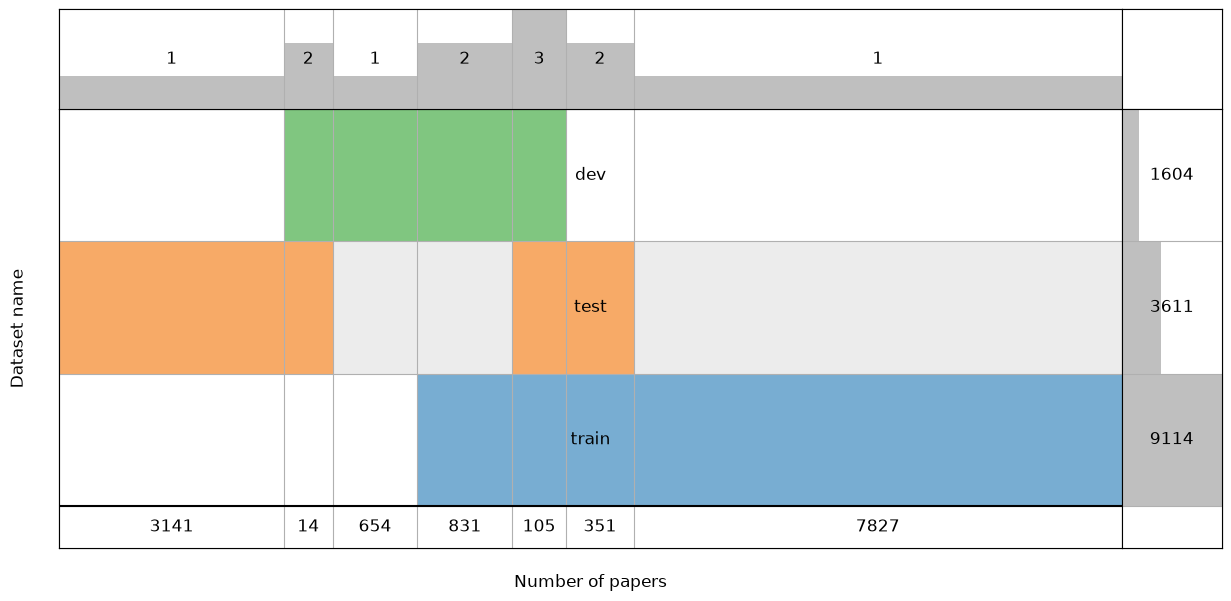

In [5]:
import matplotlib.pyplot as plt
from supervenn import supervenn

# Build the sets
sets = {}
for n, df in original_datasets.items():
    cited = set(df["citedPaperId"].dropna().unique())
    citing = set(df["citingPaperId"].dropna().unique())
    sets[n] = cited.union(citing)

# Plot the venn diagram
set_list = list(sets.values())
name_list = list(sets.keys())
plt.figure(figsize=(15, 7))
supervenn(
    set_list,
    name_list,
    widths_minmax_ratio=0.1,
    min_width_for_annotation=1
)
plt.ylabel("Dataset name", fontsize=12, labelpad=20)
plt.xlabel("Number of papers", fontsize=12, labelpad=15)
plt.show()


We can notice that many portions are shared all over the sets:
- 351 (test and train)
- 105 (test, train and dev)
- 14 (test and dev)
- 831 (dev and train)

In total there are **1301** (351+105+14+831) unique papers shared out of **12.923** (3141+351+105+14+654+831+7827) and in particular there are **936** (831+105) that are shared with the train set, so exact information leakages.

We will deal with it in the following section.

## 2. Build fully disjoint graph structures

Following the results of the previous section, we want three graphs whose node sets are pairwise disjoint, so each contested paper (one appearing in more than one split) is assigned to a single owning split. 

The choice is randomized (seeded, for reproducibility), but weighted inversely to each split's size, so a small split like `dev` is more likely to keep a contested paper than lose it to a much bigger split like `train`, since pure uniform randomness would still structurally penalize the smaller splits, and this corrects for that. Any citation edge that would cross the resulting boundary is dropped.

We build the graphs with `igraph` instead of `networkx`, since it is a thin C-backed structure, much lighter on memory for this node count, and still supports directed multigraphs (`Graph(directed=True)` with repeated edges), plus fast weakly/strongly-connected-component queries. 

In [6]:
import itertools
import random

RNG_SEED = 42
rng = random.Random(RNG_SEED)

# Assign the splits to the unique papers
paper_splits: dict[str, list[str]] = {}
for name, df in original_datasets.items():
    papers = set(df["citingPaperId"]).union(df["citedPaperId"])
    for p in papers:
        paper_splits.setdefault(p, []).append(name)

# Decide the weights inversely proportionally to the set size
split_sizes = {
    name: len(set(df["citingPaperId"]).union(df["citedPaperId"]))
    for name, df in original_datasets.items()
}
inv_weights = {name: 1.0 / split_sizes[name] for name in split_sizes}

# Decide one split for each paper which was in multiple splits
paper_owner: dict[str, str] = {}
for p, splits in paper_splits.items():
    weights = [inv_weights[s] for s in splits]
    paper_owner[p] = rng.choices(splits, weights=weights, k=1)[0]

# In each split we keep only the papers "owned" by that split
# NOTE: each edge that has an endpoint not in the set is removed
original_datasets_disjointed = {}
for name, df in original_datasets.items():
    owner_src = df["citingPaperId"].map(paper_owner)
    owner_dst = df["citedPaperId"].map(paper_owner)
    mask = (owner_src == name) & (owner_dst == name)
    original_datasets_disjointed[name] = df[mask].reset_index(drop=True)
    print(f"{name}: kept {mask.sum()} / {len(df)} rows ({(~mask).sum()} cross-split edges dropped)")


train: kept 6016 / 8137 rows (2121 cross-split edges dropped)
test: kept 1678 / 1824 rows (146 cross-split edges dropped)
dev: kept 715 / 902 rows (187 cross-split edges dropped)


In [7]:
# Sanity check: node sets must now be pairwise disjoint
node_sets = {
    name: set(df["citingPaperId"]).union(df["citedPaperId"])
    for name, df in original_datasets_disjointed.items()
}
print()
for a, b in itertools.combinations(node_sets, 2):
    overlap = node_sets[a] & node_sets[b]
    print(f"{a} \u2229 {b}: {len(overlap)} shared papers")


train ∩ test: 0 shared papers
train ∩ dev: 0 shared papers
test ∩ dev: 0 shared papers


In [8]:
import igraph as ig

def df2igraph(df: pd.DataFrame) -> ig.Graph:
    """
    Builds a directed multigraph (parallel edges allowed) with igraph, mirroring the
    old networkx-based df2graph.
    """

    edge_attributes = [
        'unique_id',
        'sectionName',
        'string',
        'label',
    ]

    nodes = sorted(set(df['citingPaperId']).union(df['citedPaperId']))
    node_index = {pid: i for i, pid in enumerate(nodes)}

    edges = list(zip(
        df['citingPaperId'].map(node_index),
        df['citedPaperId'].map(node_index),
    ))

    G = ig.Graph(n=len(nodes), edges=edges, directed=True)
    G.vs['paper_id'] = nodes
    for attr in edge_attributes:
        if attr in df.columns:
            G.es[attr] = df[attr].tolist()

    return G

In [9]:
# Core stats check
disjoint_graphs = {name: df2igraph(df) for name, df in original_datasets_disjointed.items()}
for name, G in disjoint_graphs.items():
    print(f"{name}: {G.vcount()} nodes, {G.ecount()} edges")

train: 7845 nodes, 6016 edges
test: 3337 nodes, 1678 edges
dev: 1299 nodes, 715 edges


We can see that, since nodes~edges, the splits are very sparse.

In [10]:
# Confirm disjointness at the graph level too
node_id_sets = {name: set(G.vs['paper_id']) for name, G in disjoint_graphs.items()}
for a, b in itertools.combinations(node_id_sets, 2):
    assert not (node_id_sets[a] & node_id_sets[b]), f"{a} and {b} still share nodes!"
print("All disjoint_graphs have pairwise disjoint node sets.")


All disjoint_graphs have pairwise disjoint node sets.


### 2.1 Visualization

In [11]:
import matplotlib.pyplot as plt

LABEL_COLORS = {"background": "#1c5fa7", "method": "#f22b38", "result": "#2ec11a", "cites": "#27D5D2"}

def plot_graph(G: ig.Graph, name: str, max_nodes: int = 5000, figsize: tuple = (12,12)):
    """
    Plots G with igraph's native matplotlib backend.
    Layout is computed once, server-side, and rendered as a static image, which
    is far lighter than pyvis's client-side force-directed simulation at this scale.
    
    **NOTE**: if G is too big, restrict to its largest
    weakly-connected component rather than trying to render everything.
    """

    if G.vcount() > max_nodes:
        wcc = G.connected_components(mode="weak")
        largest_idx = max(range(len(wcc)), key=lambda i: wcc.sizes()[i])
        G = wcc.subgraph(largest_idx)
        print(f"({name}) Graph too big, taking the biggest subgraph under {max_nodes} nodes: {G.vcount()} nodes")

    edge_colors = [LABEL_COLORS.get(e['label'], "#aaa") for e in G.es]

    fig, ax = plt.subplots(figsize=figsize)
    ig.plot(
        G,
        target=ax,
        layout=G.layout("fruchterman_reingold"),
        vertex_size=14,
        vertex_color="black",
        vertex_frame_color="black",
        vertex_frame_width=0.5,
        edge_color=edge_colors,
        edge_width=0.6,
        edge_arrow_size=15,
    )
    ax.set_title(name)
    ax.axis("off")

    handles = [plt.Line2D([0], [0], color=c, lw=2, label=l) for l, c in LABEL_COLORS.items()]
    fig.legend(handles=handles, loc="lower center", ncol=len(LABEL_COLORS), bbox_to_anchor=(0.5, -0.02))

    fig.tight_layout()
    fig.savefig(f"plots/{name}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    return fig

In [12]:
for name, G in disjoint_graphs.items():
    plot_graph(
        G, name, 
        max_nodes=15_000, 
        figsize=(20,20)
    )

From the images in `graphs/plots/*` we can visualize the sparsity of the splits we observed before.

## 3. Enrich the graphs with the Semantic Scholar API

This is necessary since the provided dataset is full of disconnected nodes, which block the GNN from learning through propagation.

In this section we perform a 1-hop graph expansion and an attribute enrichment, using the other Semantic Scholar API attributes that are useful for our project. This runs on `disjoint_graphs`, so the resulting `train`, `dev`, and `test` graphs stay pairwise disjoint after enrichment too, since expansion never crosses a seed node from one split into another split's graph, as each split is expanded independently.

### 3.0 Semantic Scholar API fetching utils

In [13]:
import time
import requests
from requests.adapters import HTTPAdapter, Retry
from tqdm.auto import tqdm

S2_BASE = "https://api.semanticscholar.org/graph/v1"
S2_KEY = os.environ.get("S2_API_KEY", "")
ENDPOINTS = {
    "references": f"{S2_BASE}/paper/{{id}}/references",
    "citations":  f"{S2_BASE}/paper/{{id}}/citations",
    "paper":      f"{S2_BASE}/paper/{{id}}",
    "batch":      f"{S2_BASE}/paper/batch",
}

def make_session(api_key: str = "") -> requests.Session:
    """Creates a requests session for the Semantic Scholar API."""
    session = requests.Session()
    if api_key:
        clean_key = api_key.encode("ascii", errors="ignore").decode("ascii").strip()
        session.headers.update({"x-api-key": clean_key})
    retries = Retry(
        total=0,
        status_forcelist=[500, 502, 503, 504],
        respect_retry_after_header=True,
    )
    session.mount("https://", HTTPAdapter(max_retries=retries))
    return session


class RateLimiter:
    """
    Enforces the Semantic Scholar authenticated rate limit.
    - /paper/{id}/references and most endpoints: 10 req/s
    - /paper/batch, /paper/search, /recommendations: 1 req/s
    This class only manages the steady-state delay between calls.
    Retry logic (exponential backoff on 429) lives in s2_request.
    """

    def __init__(self, base_delay: float = 0.11):
        # 0.11s is approximately 9 req/s, slightly under the 10 req/s authenticated limit.
        self.base_delay       = base_delay
        self.delay            = base_delay
        self._last_call_ts    = 0.0
        self._ok_streak       = 0

    def wait(self):
        """Sleep just enough to honor the per-second rate before each call."""
        elapsed   = time.monotonic() - self._last_call_ts
        remaining = self.delay - elapsed
        if remaining > 0:
            time.sleep(remaining)
        self._last_call_ts = time.monotonic()

    def on_success(self):
        self._ok_streak += 1
        # Gradually recover toward base_delay after backing off.
        if self.delay > self.base_delay and self._ok_streak >= 20:
            self.delay      = max(self.base_delay, self.delay * 0.75)
            self._ok_streak = 0

    def on_429(self):
        # Just nudge the steady-state delay up slightly.
        # Heavy backoff is handled per-attempt inside s2_request.
        self._ok_streak = 0
        self.delay      = min(2.0, self.delay * 1.5)


def s2_request(
    session: requests.Session,
    method: str,
    url_template: str,
    limiter: RateLimiter,
    paper_id: str | None = None,
    params: dict | None = None,
    json_body: dict | None = None,
    timeout: int = 30,
    verbose: bool = True,
    max_retries: int = 6,
) -> dict | None:
    """
    Rate-limited request wrapper with exponential backoff on 429,
    as required by Semantic Scholar's API policy.

    Backoff schedule (seconds): 2, 4, 8, 16, 32, 64.
    The limiter's wait() is called before every attempt, to respect
    the steady-state rate limit independently of retry backoff.
    """
    url = url_template.format(id=paper_id) if "{id}" in url_template else url_template

    for attempt in range(max_retries):
        limiter.wait()

        try:
            r = session.request(method, url, params=params, json=json_body, timeout=timeout)

            if r.status_code == 429:
                limiter.on_429()

                # Exponential backoff: 2^(attempt+1) seconds, capped at 64s.
                # Honor the Retry-After header if the server provides one.
                retry_after = None
                try:
                    retry_after = float(r.headers.get("Retry-After", 0)) or None
                except (ValueError, TypeError):
                    pass

                backoff = retry_after if retry_after else min(64.0, 2 ** (attempt + 1))

                if verbose:
                    tqdm.write(
                        f"  [429] attempt {attempt + 1}/{max_retries}, "
                        f"backing off {backoff:.0f}s (url: ...{url[-40:]})"
                    )
                time.sleep(backoff)
                continue  # retry - do NOT cache None for this paper

            r.raise_for_status()
            limiter.on_success()
            return r.json()

        except requests.exceptions.Timeout:
            backoff = min(64.0, 2 ** (attempt + 1))
            if verbose:
                tqdm.write(f"  [timeout] attempt {attempt + 1}/{max_retries}, retrying in {backoff:.0f}s")
            time.sleep(backoff)
            continue
        except Exception as e:
            if verbose:
                tqdm.write(f"  [request error] {method} {url}: {e}")
            return None

    if verbose:
        tqdm.write(f"  [failed] exhausted {max_retries} attempts for {url[-40:]}")
    return None


### 3.1 One-hop graph expansion

We cannot use the batch API here, because `excerpt_index` requires enumerating the per-context list, which only `/paper/{id}/references` exposes.

The edges will have the same attributes as the ones selected from the SciCite data, except for section name, which is a snippet API field and will therefore be added during the enrichment step.

Note that since `disjoint_graphs` is built to have zero overlapping papers, the reference and citation caches (`ref_cache` and `cit_cache`) are keyed by paper id and shared across the three expansions purely to avoid redundant API calls if a paper's data was already fetched in a previous run, not because of any train/dev/test leakage (there is none by construction).

In [14]:
def expand_graph_1hop(
    G: ig.Graph,
    session: requests.Session,
    limiter: RateLimiter,
    ref_limit: int = 150,
    verbose: bool = True,
    ref_cache: dict | None = None,
    cit_cache: dict | None = None,
) -> ig.Graph:
    """
    Expands G by 1 hop using both:
      - GET /paper/{id}/references, which adds cited nodes (outgoing edges)
      - GET /paper/{id}/citations, which adds citing nodes (incoming edges)

    Both directions use the same edge schema (contextsWithIntent, isInfluential).
    Does NOT mutate G (works on a copy).
    """
    fields = "paperId,contextsWithIntent,isInfluential"

    G = G.copy()
    id_to_idx = {pid: i for i, pid in enumerate(G.vs['paper_id'])}
    seed_ids = list(G.vs['paper_id'])
    new_nodes, new_edges = 0, 0

    def ensure_node(pid: str) -> int:
        nonlocal new_nodes
        if pid not in id_to_idx:
            G.add_vertices(1)
            idx = G.vcount() - 1
            G.vs[idx]['paper_id'] = pid
            G.vs[idx]['hop'] = 1
            id_to_idx[pid] = idx
            new_nodes += 1
        return id_to_idx[pid]

    pbar = tqdm(seed_ids, desc="Expanding 1-hop", dynamic_ncols=True, leave=True,
                disable=not verbose)

    for seed_id in pbar:

        # References: seed_id points to cited_id
        if ref_cache is not None and seed_id in ref_cache:
            ref_data = ref_cache[seed_id]
        else:
            ref_data = s2_request(
                session, "GET", ENDPOINTS["references"], limiter,
                paper_id=seed_id,
                params={"fields": fields, "limit": ref_limit},
                verbose=verbose,
            )
            if ref_cache is not None:
                ref_cache[seed_id] = ref_data

        for ref in (ref_data or {}).get("data") or []:
            cited    = ref.get("citedPaper") or {}
            cited_id = cited.get("paperId")
            if not cited_id or cited_id == seed_id:
                continue
            src_idx = id_to_idx[seed_id]
            dst_idx = ensure_node(cited_id)
            new_edges += _add_edges(G, src_idx, dst_idx, ref, hop=1)

        # Citations: citing_id points to seed_id
        if cit_cache is not None and seed_id in cit_cache:
            cit_data = cit_cache[seed_id]
        else:
            cit_data = s2_request(
                session, "GET", ENDPOINTS["citations"], limiter,
                paper_id=seed_id,
                params={"fields": fields, "limit": ref_limit},
                verbose=verbose,
            )
            if cit_cache is not None:
                cit_cache[seed_id] = cit_data

        for cit in (cit_data or {}).get("data") or []:
            citing    = cit.get("citingPaper") or {}   # symmetric to citedPaper
            citing_id = citing.get("paperId")
            if not citing_id or citing_id == seed_id:
                continue
            dst_idx = id_to_idx[seed_id]
            src_idx = ensure_node(citing_id)
            new_edges += _add_edges(G, src_idx, dst_idx, cit, hop=1)

        pbar.set_postfix(new_nodes=new_nodes, new_edges=new_edges)

    return G


def _add_edges(
    G: ig.Graph,
    src_idx: int,
    dst_idx: int,
    record: dict,
    hop: int,
) -> int:
    """Adds one or more edges from a single API record (references or citations).
    Returns the number of edges added."""
    is_influential = record.get("isInfluential", False)
    cwi_list = record.get("contextsWithIntent") or [{}]
    src_id = G.vs[src_idx]['paper_id']
    dst_id = G.vs[dst_idx]['paper_id']

    added = 0
    for excerpt_index, cwi in enumerate(cwi_list):
        context  = cwi.get("context", "")
        intents  = cwi.get("intents") or []
        label    = intents[0] if intents else "cites"
        unique_id = f"{src_id}>{dst_id}_{excerpt_index}"

        G.add_edge(
            src_idx, dst_idx,
            unique_id=unique_id,
            string=context,
            label=label,
            is_influential=is_influential,
            hop=hop,
        )
        added += 1

    return added


In [15]:
# Caching helpers
import pickle

os.makedirs("cache", exist_ok=True)

def load_cache(path: str) -> dict:
    """Loads a pickle cache, tolerating a missing or corrupted (truncated) file."""
    if not os.path.exists(path):
        return {}
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except (EOFError, pickle.UnpicklingError) as e:
        backup = path + ".broken"
        os.replace(path, backup)
        print(f"[cache] {path} was corrupted ({e}), moved to {backup}, starting fresh.")
        return {}

def save_cache(path: str, obj: dict) -> None:
    """Atomically writes a pickle cache: write to a temp file, then rename over the
    original. os.replace is atomic on POSIX/Windows, so a crash or interrupt mid-write
    can never leave a truncated cache file behind."""
    tmp_path = path + ".tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(obj, f)
    os.replace(tmp_path, path)

In [16]:
CHECKPOINT_EVERY = 1
FIELDS = "paperId,contextsWithIntent,isInfluential"

ref_cache = load_cache("cache/ref_cache.pkl")
cit_cache = load_cache("cache/cit_cache.pkl")
expanded_graphs = load_cache("cache/expanded_graphs.pkl") or {}

limiter = RateLimiter()
session = make_session(S2_KEY)

all_paper_ids = set()
for G in disjoint_graphs.values():
    all_paper_ids |= set(G.vs['paper_id'])

missing_refs = all_paper_ids - ref_cache.keys()
missing_cits = all_paper_ids - cit_cache.keys()
print(f"Papers: {len(all_paper_ids)}, "
      f"refs to fetch: {len(missing_refs)}, "
      f"cits to fetch: {len(missing_cits)}")

# Pre-fetch references
if len(missing_refs) > 0:
    for i, paper_id in enumerate(tqdm(missing_refs, desc="Pre-fetching references")):
        ref_cache[paper_id] = s2_request(
            session, "GET", ENDPOINTS["references"], limiter,
            paper_id=paper_id, params={"fields": FIELDS, "limit": 150},
        )
        if (i + 1) % CHECKPOINT_EVERY == 0:
            save_cache("cache/ref_cache.pkl", ref_cache)

save_cache("cache/ref_cache.pkl", ref_cache)

# Pre-fetch citations
if len(missing_cits) > 0:
    for i, paper_id in enumerate(tqdm(missing_cits, desc="Pre-fetching citations")):
        cit_cache[paper_id] = s2_request(
            session, "GET", ENDPOINTS["citations"], limiter,
            paper_id=paper_id, params={"fields": FIELDS, "limit": 150},
        )
        if (i + 1) % CHECKPOINT_EVERY == 0:
            save_cache("cache/cit_cache.pkl", cit_cache)

save_cache("cache/cit_cache.pkl", cit_cache)

# Build expanded graphs from cache (no more API calls here)
for n, G in disjoint_graphs.items():
    print(f"{'#' * 70} {n} {'#' * 70}")
    if n in expanded_graphs:
        print("Loaded from pickle.")
        continue
    expanded_graphs[n] = expand_graph_1hop(
        G, session, limiter,
        ref_cache=ref_cache, cit_cache=cit_cache,
    )
    save_cache("cache/expanded_graphs.pkl", expanded_graphs)


Papers: 12481, refs to fetch: 0, cits to fetch: 0
###################################################################### train ######################################################################
Loaded from pickle.
###################################################################### test ######################################################################
Loaded from pickle.
###################################################################### dev ######################################################################
Loaded from pickle.


### 3.2 Re-enforce disjointness after enrichment

The 1-hop expansion pulls in references and citations from the Semantic Scholar API independently for each split, and nothing stops the same neighbor paper from being added to more than one split's expansion, since a highly-cited paper can easily show up as a 1-hop neighbor of both a `train` seed and a `test` seed. So `expanded_graphs` is not guaranteed disjoint anymore, even though the pre-expansion `` were.

We apply the same size-weighted tie-break as before: each contested paper is assigned to a single owning split, with probability weighted inversely to that split's current node count (same seed as before), and we take the induced subgraph on the papers each split still owns, which drops any node (and its incident edges) that ended up owned by another split.

In [17]:
rng = random.Random(RNG_SEED)

paper_splits_expanded: dict[str, list[str]] = {}
for name, G in expanded_graphs.items():
    for pid in G.vs['paper_id']:
        paper_splits_expanded.setdefault(pid, []).append(name)

split_sizes_expanded = {name: G.vcount() for name, G in expanded_graphs.items()}
inv_weights_expanded = {name: 1.0 / split_sizes_expanded[name] for name in split_sizes_expanded}

paper_owner_expanded: dict[str, str] = {}
for p, splits in paper_splits_expanded.items():
    weights = [inv_weights_expanded[s] for s in splits]
    paper_owner_expanded[p] = rng.choices(splits, weights=weights, k=1)[0]

disjoint_expanded_graphs = {}
for name, G in expanded_graphs.items():
    keep_idx = [v.index for v in G.vs if paper_owner_expanded[v['paper_id']] == name]
    G_disjoint = G.induced_subgraph(keep_idx)
    disjoint_expanded_graphs[name] = G_disjoint
    print(f"{name}: kept {G_disjoint.vcount()} / {G.vcount()} nodes, "
          f"{G_disjoint.ecount()} / {G.ecount()} edges")

train: kept 639680 / 654867 nodes, 953437 / 997790 edges
test: kept 275438 / 281536 nodes, 405888 / 421280 edges
dev: kept 104590 / 106072 nodes, 154703 / 159647 edges


In [18]:
# Sanity check: node sets must be pairwise disjoint again
print()
node_sets = {name: set(G.vs['paper_id']) for name, G in disjoint_expanded_graphs.items()}
for a, b in itertools.combinations(node_sets, 2):
    overlap = node_sets[a] & node_sets[b]
    assert not overlap, f"{a} and {b} still share nodes!"
    print(f"{a} \u2229 {b}: {len(overlap)} shared papers")


train ∩ test: 0 shared papers
train ∩ dev: 0 shared papers
test ∩ dev: 0 shared papers


### 3.3 Expanded (and disjointed) graph inspection

Since the expanded graphs showed a lot of new edges and nodes, it is appropriate to inspect what these numbers actually look like.

#### 3.3.1 Graph statistics

In [19]:
import numpy as np
from collections import Counter
from typing import Dict, Union, List

def get_gnn_graph_stats(G: ig.Graph) -> dict:
    """
    Analyzes a large igraph Graph to extract structural metrics relevant
    for Graph Neural Network (GNN) processing, avoiding computationally
    expensive algorithms.
    """
    stats = {}

    # 1. Core dimensions
    stats['num_nodes'] = G.vcount()
    stats['num_edges_total'] = G.ecount()

    if stats['num_nodes'] == 0:
        return stats

    # Multigraph and self-loop metrics
    edge_pairs = [(e.source, e.target) for e in G.es]
    unique_edges = set(edge_pairs)
    stats['num_edges_unique'] = len(unique_edges)

    if stats['num_edges_total'] > 0:
        counts = Counter(edge_pairs)
        stats['max_parallel_edges'] = max(counts.values())
    else:
        stats['max_parallel_edges'] = 0

    stats['num_self_loops'] = sum(1 for s, t in edge_pairs if s == t)

    # 2. Weakly connected components (WCC), the graph's "islands"
    wcc_sizes: List[int] = sorted(G.connected_components(mode="weak").sizes(), reverse=True)

    stats['num_wcc_total'] = len(wcc_sizes)
    stats['wcc_size_max'] = wcc_sizes[0]
    stats['wcc_size_avg'] = float(np.mean(wcc_sizes))
    stats['num_isolated_nodes'] = sum(1 for size in wcc_sizes if size == 1)
    stats['top_5_wcc_sizes'] = wcc_sizes[:5]
    stats['giant_component_ratio'] = wcc_sizes[0] / stats['num_nodes']

    # 3. Strongly connected components (SCC)
    scc_sizes: List[int] = sorted(G.connected_components(mode="strong").sizes(), reverse=True)

    stats['num_scc_total'] = len(scc_sizes)
    stats['scc_size_max'] = scc_sizes[0]

    # 4. Degree statistics
    in_degrees = G.indegree()
    out_degrees = G.outdegree()

    stats['deg_in_max'] = int(np.max(in_degrees))
    stats['deg_in_avg'] = float(np.mean(in_degrees))
    stats['deg_out_max'] = int(np.max(out_degrees))
    stats['deg_out_avg'] = float(np.mean(out_degrees))

    stats['density'] = float(G.density())

    return stats


In [20]:
stats_results = {}
for n, G in disjoint_expanded_graphs.items():
    stats_results[n] = get_gnn_graph_stats(G)
df_stats = pd.DataFrame.from_dict(stats_results, orient='index')
df_stats.index.name = 'dataset_name'
df_stats = df_stats.reset_index()
df_stats


,dataset_name,num_nodes,num_edges_total,num_edges_unique,max_parallel_edges,num_self_loops,num_wcc_total,wcc_size_max,wcc_size_avg,num_isolated_nodes,top_5_wcc_sizes,giant_component_ratio,num_scc_total,scc_size_max,deg_in_max,deg_in_avg,deg_out_max,deg_out_avg,density
0,train,639680,953437,655002,179,0,10479,575220,61.043993,9897,"[575220, 542, 488, 460, 448]",0.899231,639572,6,544,1.490491,532,1.490491,0.000002
1,test,275438,405888,280046,76,0,3925,209301,70.175287,3414,"[209301, 645, 625, 575, 550]",0.759884,275377,8,373,1.473609,464,1.473609,0.000005
2,dev,104590,154703,105272,54,0,2048,22789,51.069336,1672,"[22789, 16254, 2355, 1370, 1002]",0.217889,104568,7,420,1.479138,461,1.479138,0.000014


We have to notice some points:
- `dev` is structurally different, also proportionally, from the other splits. The `giant_component_ratio` is far smaller and shows that there is no real network there and it will be problematic for validation and probaly will show worse performances.
- `deg_in_avg` and `deg_out_avg` are very small and suggest a chain structure with one input and one output.
- It is unexpected to see `scc_size_max` grater than 0, meaning that there are loops between papers. It is unexpected because there is the time component that divides an edge, as you can't cite a paper that us publicated after your puplication.

#### 3.3.2 Deeper morphological view

In [21]:
MAX_NODES_FOR_DIAMETER = 500

def analyze_component_shapes(G: ig.Graph) -> pd.DataFrame:
    wcc = G.connected_components(mode="weak")
    sizes = wcc.sizes()
    giant_comp_id = int(np.argmax(sizes))

    rows = []
    for comp_id, size in enumerate(sizes):
        if comp_id == giant_comp_id or size < 2:
            continue  

        node_idx = [i for i, m in enumerate(wcc.membership) if m == comp_id]
        sub = G.induced_subgraph(node_idx)

        degrees = sub.degree(mode="all")
        frac_deg2 = sum(1 for d in degrees if d == 2) / size
        max_deg = max(degrees)

        diameter = None
        linearity = None
        if size <= MAX_NODES_FOR_DIAMETER:
            diameter = sub.diameter(directed=False, unconn=True)
            linearity = diameter / (size - 1) if size > 1 else None

        rows.append({
            "size": size,
            "diameter": diameter,
            "linearity": linearity,
            "frac_deg2": frac_deg2,
            "max_deg": max_deg,
        })

    return pd.DataFrame(rows)

component_shapes = {}
for name, G in disjoint_expanded_graphs.items():
    component_shapes[name] = analyze_component_shapes(G)

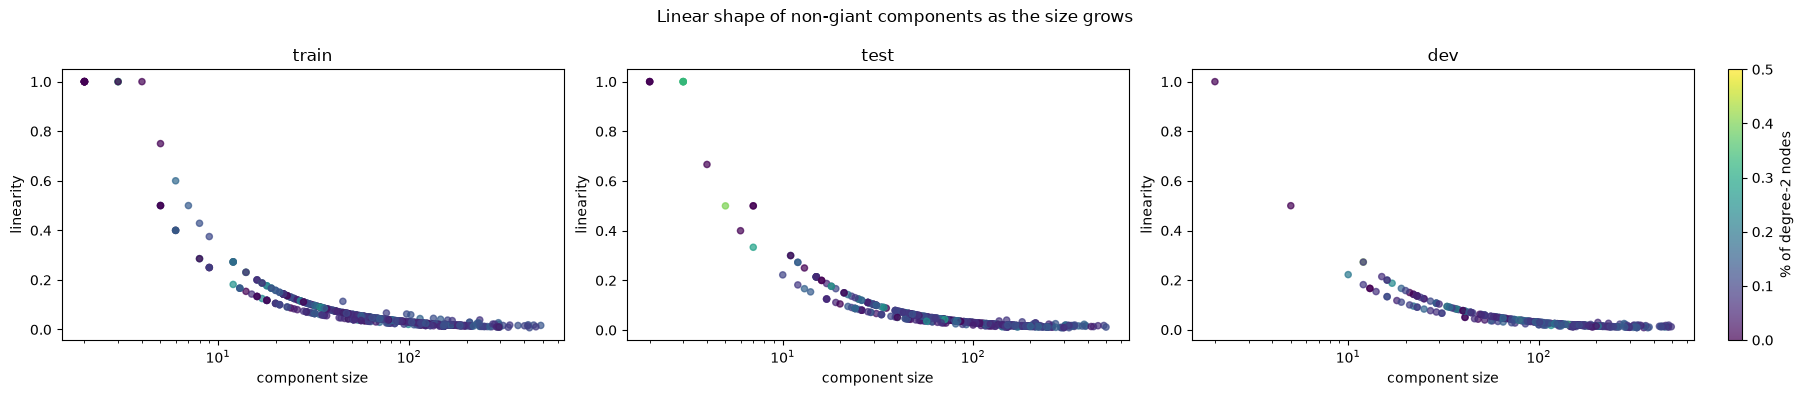

In [22]:
vmin, vmax = 0.0, 0.5

fig, axes = plt.subplots(1, len(component_shapes), figsize=(6 * len(component_shapes), 4))
if len(component_shapes) == 1:
    axes = [axes]
fig.suptitle("Linear shape of non-giant components as the size grows")

sc = None  # keep only the last colorbar
for ax, (name, df_shapes) in zip(axes, component_shapes.items()):
    df_valid = df_shapes.dropna(subset=["linearity"])
    sc = ax.scatter(df_valid["size"], df_valid["linearity"],
                     c=df_valid["frac_deg2"], cmap="viridis", s=20, alpha=0.7,
                     vmin=vmin, vmax=vmax)
    ax.set_title(f"{name}")
    ax.set_xlabel("component size")
    ax.set_ylabel("linearity")
    ax.set_xscale("log")

plt.tight_layout()
fig.colorbar(sc, ax=axes, label="% of degree-2 nodes", fraction=0.03, pad=0.02)
plt.show()

Linearity drops sharply as size grows in every split, following roughly a 1/size curve. This is the signature of a [hub-and-spoke](https://en.wikipedia.org/wiki/Spoke%E2%80%93hub_distribution_paradigm) structure, not a chain. 

The color stays low across the board, reinforcing that pass-through nodes are the exception, not the rule.

In [23]:
# The colorbar above does not help that much in uderstanding 
# the types of the node degrees that we have in the splits

MAX_NODES_FOR_SHAPE = 500  # keep in sync with the diameter cutoff above

def analyze_degree_breakdown(G: ig.Graph) -> pd.DataFrame:
    wcc = G.connected_components(mode="weak")
    sizes = wcc.sizes()
    giant_comp_id = int(np.argmax(sizes))

    rows = []
    for comp_id, size in enumerate(sizes):
        if comp_id == giant_comp_id or size < 2:
            continue 

        node_idx = [i for i, m in enumerate(wcc.membership) if m == comp_id]
        sub = G.induced_subgraph(node_idx)
        degrees = sub.degree(mode="all")

        n_leaf = sum(1 for d in degrees if d == 1)
        n_deg2 = sum(1 for d in degrees if d == 2)
        n_hub_like = sum(1 for d in degrees if d >= 3)

        rows.append({
            "size": size,
            "frac_leaf": n_leaf / size,
            "frac_deg2": n_deg2 / size,
            "frac_hub_like": n_hub_like / size,
            "max_deg": max(degrees),
        })

    return pd.DataFrame(rows)

degree_breakdown = {}
for name, G in disjoint_expanded_graphs.items():
    degree_breakdown[name] = analyze_degree_breakdown(G)

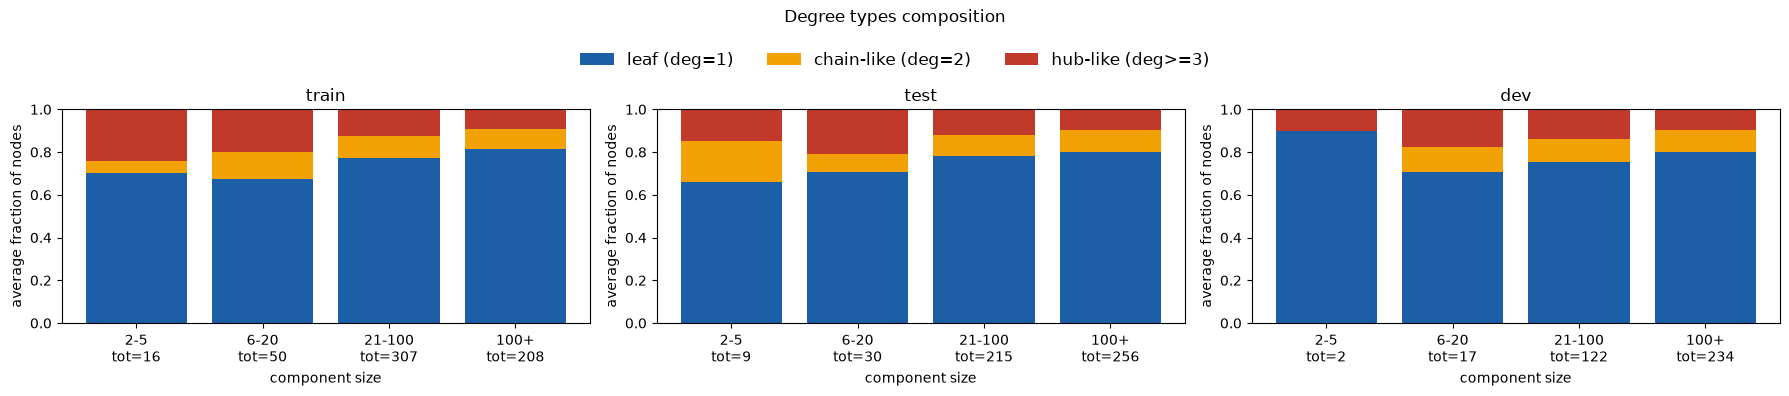

In [24]:
fig, axes = plt.subplots(1, len(degree_breakdown), figsize=(6 * len(degree_breakdown), 4))
if len(degree_breakdown) == 1:
    axes = [axes]
fig.suptitle("Degree types composition")
size_bins = [2, 6, 21, 101, np.inf]
bin_labels = ["2-5", "6-20", "21-100", "100+"]
colors = {"frac_leaf": "#1c5fa7", "frac_deg2": "#f2a104", "frac_hub_like": "#c0392b"}
labels = {"frac_leaf": "leaf (deg=1)", "frac_deg2": "chain-like (deg=2)", "frac_hub_like": "hub-like (deg>=3)"}

handles_for_legend = None
for ax, (name, df_breakdown) in zip(axes, degree_breakdown.items()):
    df_b = df_breakdown.copy()
    df_b["size_bin"] = pd.cut(df_b["size"], bins=size_bins, labels=bin_labels, right=False)

    grouped = df_b.groupby("size_bin", observed=True)[["frac_leaf", "frac_deg2", "frac_hub_like"]].mean()
    grouped = grouped.reindex(bin_labels)

    counts = df_b.groupby("size_bin", observed=True).size().reindex(bin_labels).fillna(0).astype(int)
    xtick_labels = [f"{lbl}\ntot={n}" for lbl, n in zip(bin_labels, counts)]

    bottom = np.zeros(len(grouped))
    for col in ["frac_leaf", "frac_deg2", "frac_hub_like"]:
        vals = grouped[col].fillna(0).values
        bars = ax.bar(bin_labels, vals, bottom=bottom, color=colors[col], label=labels[col])
        bottom += vals
    handles_for_legend = ax.get_legend_handles_labels()  

    ax.set_title(f"{name}")
    ax.set_ylabel("average fraction of nodes")
    ax.set_xlabel("component size")
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(xtick_labels)
    ax.set_ylim(0, 1)

fig.legend(*handles_for_legend, loc="upper center", bbox_to_anchor=(0.5, 0.91),
           ncol=3, fontsize=12, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

This confirms the previous idea of central hubs with many leaves and this is positive for message passing as improves nodes reachability. More importantly this trend is quite the same as the component varies, making it a robust assumption.

In [25]:
# For each non-giant component, take its highest-degree node as the "hub"
# and compute the shortest-path distance from that hub to every other node
# in the component. 

# NOTE: if the structure is truly hub-and-spoke, the vast majority of nodes 
# should sit at distance 1. A meaningful tail at distance >=2 would mean 
# spokes have their own sub-branches rather than attaching directly to the hub.

def analyze_hub_distances(G: ig.Graph) -> pd.DataFrame:
    wcc = G.connected_components(mode="weak")
    sizes = wcc.sizes()
    giant_comp_id = int(np.argmax(sizes))

    rows = []
    for comp_id, size in enumerate(sizes):
        if comp_id == giant_comp_id or size < 2:
            continue
        if size > MAX_NODES_FOR_SHAPE:
            continue  # keep shortest-path computation cheap, same cutoff as before

        node_idx = [i for i, m in enumerate(wcc.membership) if m == comp_id]
        sub = G.induced_subgraph(node_idx)
        degrees = sub.degree(mode="all")
        hub_idx = int(np.argmax(degrees))

        dists = sub.distances(source=[hub_idx], mode="all")[0]
        dists = [d for i, d in enumerate(dists) if i != hub_idx]  # exclude the hub itself

        rows.append({
            "size": size,
            "frac_at_dist_1": sum(1 for d in dists if d == 1) / len(dists) if dists else np.nan,
            "max_dist_from_hub": max(dists) if dists else 0,
        })

    return pd.DataFrame(rows)

hub_distances = {}
for name, G in disjoint_expanded_graphs.items():
    df_hub = analyze_hub_distances(G)
    hub_distances[name] = df_hub
    print(f"{name}: \t median max_dist_from_hub = {df_hub['max_dist_from_hub'].median():.0f}, \t"
          f"worst case = {df_hub['max_dist_from_hub'].max():.0f} "
          f"(n={len(df_hub)} components, size <= {MAX_NODES_FOR_SHAPE})")

train: 	 median max_dist_from_hub = 2, 	worst case = 6 (n=580 components, size <= 500)
test: 	 median max_dist_from_hub = 2, 	worst case = 8 (n=504 components, size <= 500)
dev: 	 median max_dist_from_hub = 2, 	worst case = 7 (n=360 components, size <= 500)


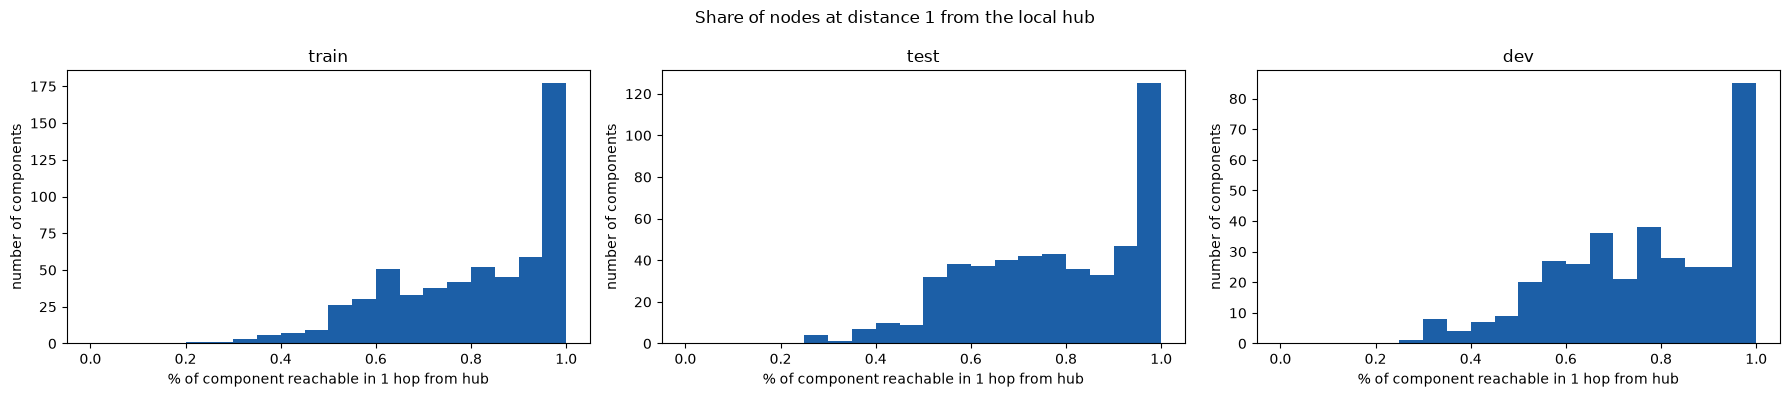

In [26]:
fig, axes = plt.subplots(1, len(hub_distances), figsize=(6 * len(hub_distances), 4))
if len(hub_distances) == 1:
    axes = [axes]
fig.suptitle("Share of nodes at distance 1 from the local hub")

for ax, (name, df_hub) in zip(axes, hub_distances.items()):
    df_valid = df_hub.dropna(subset=["frac_at_dist_1"])
    ax.hist(df_valid["frac_at_dist_1"], bins=20, range=(0, 1), color="#1c5fa7")
    ax.set_title(f"{name}")
    ax.set_xlabel(f"% of component reachable in 1 hop from hub")
    ax.set_ylabel("number of components")

plt.tight_layout()
plt.show()

Mass concentrates near 1.0 in all three splits, with dev showing a somewhat heavier tail toward lower values than train/test. Combined with max_dist_from_hub (median 2, worst case 6-7 hops, printed above), most non-giant components are near-pure hub-and-spoke, with a smaller subset where spokes branch out one extra level (hub-of-hubs) rather than attaching directly to the main hub.

#### 3.3.3 Dive inside `dev`

In [27]:
print("giant_component_ratio: pre-expansion vs post-expansion\n")
for name in disjoint_graphs:
    G_pre = disjoint_graphs[name]
    G_post = disjoint_expanded_graphs[name]

    pre_giant = max(G_pre.connected_components(mode="weak").sizes())
    post_giant = max(G_post.connected_components(mode="weak").sizes())

    print(f"{name}: \t pre={pre_giant}/{G_pre.vcount()} ({100*pre_giant/G_pre.vcount():.1f}%), "
          f"\t post={post_giant}/{G_post.vcount()} ({100*post_giant/G_post.vcount():.1f}%)")

giant_component_ratio: pre-expansion vs post-expansion

train: 	 pre=4/7845 (0.1%), 	 post=575220/639680 (89.9%)
test: 	 pre=3/3337 (0.1%), 	 post=209301/275438 (76.0%)
dev: 	 pre=3/1299 (0.2%), 	 post=22789/104590 (21.8%)


All three splits start from a near-empty giant component before expansion (0.1-0.2%), so the 1-hop enrichment step is doing real structural work everywhere. After expansion, train and test land in the 76-90% range, while dev only reaches ~22%. Dev did benefit from the 1-hop expansion, but nowhere near as much as the other two splits.

In [28]:
G_dev_pre = disjoint_graphs["dev"]
G_dev_post = disjoint_expanded_graphs["dev"]

original_seed_ids = set(G_dev_pre.vs["paper_id"])
membership = G_dev_post.connected_components(mode="weak").membership
sizes = G_dev_post.connected_components(mode="weak").sizes()
giant_comp_id = max(range(len(sizes)), key=lambda i: sizes[i])

giant_ids, non_giant_ids = set(), set()
for i in range(G_dev_post.vcount()):
    pid = G_dev_post.vs[i]["paper_id"]
    (giant_ids if membership[i] == giant_comp_id else non_giant_ids).add(pid)

giant_seeds = giant_ids & original_seed_ids
giant_new = giant_ids - original_seed_ids
non_giant_seeds = non_giant_ids & original_seed_ids
non_giant_new = non_giant_ids - original_seed_ids

print(f"dev before expansion: {len(original_seed_ids)} seeds\n")
print(f"dev after expansion:  {G_dev_post.vcount()} nodes total")
print(f"  inside giant component:     {len(giant_ids):>7} "
      f"({len(giant_seeds)} original seeds + {len(giant_new)} new nodes)")
print(f"  outside giant component:    {len(non_giant_ids):>7} "
      f"({len(non_giant_seeds)} original seeds + {len(non_giant_new)} new nodes)")
print(f"\nOf the {G_dev_post.vcount() - len(original_seed_ids)} nodes gained through expansion, "
      f"{100*len(giant_new)/(len(giant_new)+len(non_giant_new)):.1f}% ended up inside the giant "
      f"component and {100*len(non_giant_new)/(len(giant_new)+len(non_giant_new)):.1f}% outside it.")

dev before expansion: 1299 seeds

dev after expansion:  104590 nodes total
  inside giant component:       22789 (196 original seeds + 22593 new nodes)
  outside giant component:      81801 (880 original seeds + 80921 new nodes)

Of the 103291 nodes gained through expansion, 21.8% ended up inside the giant component and 78.2% outside it.


The growth is heavily lopsided: of the ~103k nodes gained through expansion, only 21.8% landed inside the giant component, the rest (78.2%) scattered outside it, mostly as new leaves attached to seeds that never merged with anything else. 

The giant component itself is now almost entirely new nodes (22566 vs. 223 original seeds), which means expanding *further* from nodes already inside it is a reasonable way to grow it.

#### 3.3.4 Another expansion of `dev` split.

We need to expand the giant component of dev to alignt it to other splits proportionally.

1. Select a subsample of nodes that are already inside dev's giant component but have never themselves been queried against the Semantic Scholar API as they only exist as *discovered* endpoints of some seed's 1-hop expansion (so their real degree is unknown). We pick them by current degree in `disjoint_expanded_graphs["dev"]`, as a proxy for how well-connected they are likely to be.
2. Expand those nodes by one more hop (references + citations), the same way section 3.1 does.
3. Filter disjointness inline during discovery, instead of re-enforcing it afterwards: a newly discovered node is only accepted into `dev` if it isn't already a node of `disjoint_expanded_graphs["train"]` or `disjoint_expanded_graphs["test"]`. This guarantees every accepted node stays in `dev`, with no lottery step needed after the fact, so we don't change other split as side effect.

This intentionally does **not** touch `dev`'s isolated seed pairs, 3.3.3 showed that 78.2% of the mass gained through the original 1-hop expansion landed outside the giant component anyway, so expanding from inside the giant component is the more promising direction to pursue.

In [29]:
N_TO_EXPAND = 500  

DEV_TARGETED_EXPANSION_PATH = f"cache/dev_targeted_expansion_N={N_TO_EXPAND}.pkl"
dev_targeted_expansion = load_cache(DEV_TARGETED_EXPANSION_PATH)

if "dev" in dev_targeted_expansion:
    print(f"Loaded from {DEV_TARGETED_EXPANSION_PATH}, skipping expansion.")
    G_dev_v2 = dev_targeted_expansion["dev"]
else:
    G_dev = disjoint_expanded_graphs["dev"]
    components = G_dev.connected_components(mode="weak")
    sizes = components.sizes()
    giant_comp_id = max(range(len(sizes)), key=lambda i: sizes[i])
    membership = components.membership

    original_seed_ids = set(disjoint_graphs["dev"].vs["paper_id"])
    giant_ids = {
        G_dev.vs[i]["paper_id"] for i in range(G_dev.vcount()) if membership[i] == giant_comp_id
    }
    giant_new_never_queried = [
        pid for pid in (giant_ids - original_seed_ids)
        if pid not in ref_cache and pid not in cit_cache
    ]

    degree_lookup = {G_dev.vs[i]["paper_id"]: G_dev.degree(i, mode="all") for i in range(G_dev.vcount())}
    giant_new_never_queried.sort(key=lambda pid: -degree_lookup.get(pid, 0))

    seeds_to_expand = giant_new_never_queried[:N_TO_EXPAND]
    print(f"Eligible pool (giant, new, never queried): {len(giant_new_never_queried)}")
    print(f"Expanding: {len(seeds_to_expand)}")

    already_in_other_splits = (
        set(disjoint_expanded_graphs["train"].vs["paper_id"]) |
        set(disjoint_expanded_graphs["test"].vs["paper_id"])
    )

    fields = "paperId,contextsWithIntent,isInfluential"
    n_accepted_refs, n_accepted_cits = 0, 0
    n_rejected_other_split, n_rejected_self = 0, 0

    id_to_idx_dev = {pid: i for i, pid in enumerate(G_dev.vs["paper_id"])}
    n_existing = G_dev.vcount()
    new_node_ids, new_node_local_idx = [], {}
    edge_pairs, edge_unique_id, edge_string, edge_label, edge_is_influential, edge_hop = [], [], [], [], [], []

    def ensure_node_idx(pid):
        if pid in id_to_idx_dev:
            return id_to_idx_dev[pid]
        if pid in new_node_local_idx:
            return new_node_local_idx[pid]
        idx = n_existing + len(new_node_ids)
        new_node_ids.append(pid)
        new_node_local_idx[pid] = idx
        return idx

    def record_edges(seed_id, other_id, record, seed_is_src, hop):
        if seed_is_src:
            src_idx, dst_idx = ensure_node_idx(seed_id), ensure_node_idx(other_id)
            src_id, dst_id = seed_id, other_id
        else:
            dst_idx, src_idx = ensure_node_idx(seed_id), ensure_node_idx(other_id)
            src_id, dst_id = other_id, seed_id

        cwi_list = record.get("contextsWithIntent") or [{}]
        is_influential = record.get("isInfluential", False)
        for excerpt_index, cwi in enumerate(cwi_list):
            edge_pairs.append((src_idx, dst_idx))
            edge_unique_id.append(f"{src_id}>{dst_id}_{excerpt_index}")
            edge_string.append(cwi.get("context", ""))
            intents = cwi.get("intents") or []
            edge_label.append(intents[0] if intents else "cites")
            edge_is_influential.append(is_influential)
            edge_hop.append(hop)

    for seed_id in tqdm(seeds_to_expand, desc="Targeted 2nd-hop expansion"):
        if seed_id in ref_cache:
            ref_data = ref_cache[seed_id]
        else:
            ref_data = s2_request(session, "GET", ENDPOINTS["references"], limiter,
                                   paper_id=seed_id, params={"fields": fields, "limit": 150}, verbose=False)
            ref_cache[seed_id] = ref_data

        for ref in (ref_data or {}).get("data") or []:
            cited_id = (ref.get("citedPaper") or {}).get("paperId")
            if not cited_id or cited_id == seed_id:
                n_rejected_self += 1
                continue
            if cited_id in already_in_other_splits:
                n_rejected_other_split += 1
                continue
            record_edges(seed_id, cited_id, ref, seed_is_src=True, hop=2)
            n_accepted_refs += 1

        if seed_id in cit_cache:
            cit_data = cit_cache[seed_id]
        else:
            cit_data = s2_request(session, "GET", ENDPOINTS["citations"], limiter,
                                   paper_id=seed_id, params={"fields": fields, "limit": 150}, verbose=False)
            cit_cache[seed_id] = cit_data

        for cit in (cit_data or {}).get("data") or []:
            citing_id = (cit.get("citingPaper") or {}).get("paperId")
            if not citing_id or citing_id == seed_id:
                n_rejected_self += 1
                continue
            if citing_id in already_in_other_splits:
                n_rejected_other_split += 1
                continue
            record_edges(seed_id, citing_id, cit, seed_is_src=False, hop=2)
            n_accepted_cits += 1

    print(f"\nAccepted new edges: {n_accepted_refs} from references, {n_accepted_cits} from citations "
          f"({100*n_accepted_refs/max(n_accepted_refs+n_accepted_cits,1):.0f}% / "
          f"{100*n_accepted_cits/max(n_accepted_refs+n_accepted_cits,1):.0f}% split)")
    print(f"Rejected (already in train/test): {n_rejected_other_split}")
    print(f"Rejected (self-loop): {n_rejected_self}")
    print(f"Net new distinct nodes: {len(new_node_ids)}")

    G_dev_v2 = G_dev.copy()
    if new_node_ids:
        G_dev_v2.add_vertices(len(new_node_ids))
        G_dev_v2.vs[n_existing:]['paper_id'] = new_node_ids
        G_dev_v2.vs[n_existing:]['hop'] = [2] * len(new_node_ids)
    if edge_pairs:
        n_edges_before = G_dev_v2.ecount()
        G_dev_v2.add_edges(edge_pairs)
        G_dev_v2.es[n_edges_before:]['unique_id'] = edge_unique_id
        G_dev_v2.es[n_edges_before:]['string'] = edge_string
        G_dev_v2.es[n_edges_before:]['label'] = edge_label
        G_dev_v2.es[n_edges_before:]['is_influential'] = edge_is_influential
        G_dev_v2.es[n_edges_before:]['hop'] = edge_hop

    dev_targeted_expansion["dev"] = G_dev_v2
    save_cache(DEV_TARGETED_EXPANSION_PATH, dev_targeted_expansion)

Loaded from cache/dev_targeted_expansion_N=500.pkl, skipping expansion.


In [30]:
final_disjoint_graphs = {
    "train": disjoint_expanded_graphs["train"],
    "test": disjoint_expanded_graphs["test"],
    "dev": G_dev_v2,
}

#### 3.3.5 Small checks and fixes 

In [31]:
# Removing isolated nodes (degree 0)
# These nodes carry no structural signal at all and will contribute nothing 

for name, G in final_disjoint_graphs.items():
    n_before = G.vcount()
    isolated_idx = [v.index for v in G.vs if G.degree(v.index, mode="all") == 0]
    G.delete_vertices(isolated_idx)
    print(f"{name}: removed {len(isolated_idx)} isolated nodes ({n_before} -> {G.vcount()})")

train: removed 9897 isolated nodes (639680 -> 629783)
test: removed 3414 isolated nodes (275438 -> 272024)
dev: removed 1665 isolated nodes (134435 -> 132770)


In [32]:
stats_results = {}
for n, G in final_disjoint_graphs.items():
    stats_results[n] = get_gnn_graph_stats(G)
df_stats = pd.DataFrame.from_dict(stats_results, orient='index')
df_stats.index.name = 'dataset_name'
df_stats = df_stats.reset_index()
df_stats


,dataset_name,num_nodes,num_edges_total,num_edges_unique,max_parallel_edges,num_self_loops,num_wcc_total,wcc_size_max,wcc_size_avg,num_isolated_nodes,top_5_wcc_sizes,giant_component_ratio,num_scc_total,scc_size_max,deg_in_max,deg_in_avg,deg_out_max,deg_out_avg,density
0,train,629783,953437,655002,179,0,582,575220,1082.101375,0,"[575220, 542, 488, 460, 448]",0.913362,629675,6,544,1.513914,532,1.513914,0.000002
1,test,272024,405888,280046,76,0,511,209301,532.336595,0,"[209301, 645, 625, 575, 550]",0.769421,271963,8,373,1.492104,464,1.492104,0.000005
2,dev,132770,218928,143373,54,0,324,85284,409.783951,0,"[85284, 799, 728, 609, 531]",0.642344,132724,8,420,1.648927,801,1.648927,0.000012


In [33]:
# Sanity check: node sets must now be pairwise disjoint
node_sets = {
    name: set(G.vs["paper_id"])
    for name, G in final_disjoint_graphs.items()
}
print()
for a, b in itertools.combinations(node_sets, 2):
    overlap = node_sets[a] & node_sets[b]
    print(f"{a} ∩ {b}: {len(overlap)} shared papers")


train ∩ test: 0 shared papers
train ∩ dev: 0 shared papers
test ∩ dev: 0 shared papers


Ok now the `dev` expansion allows a `giant_component_ratio` of 64% which is more similar to other splits, while the others stats are quite invariate so we can continue.

### 3.4 Node feature enrichment (embeddings and metadata)

The 1-hop expansion above only added nodes and citation edges; the nodes themselves still carry no metadata beyond `paper_id`. This section fetches per-paper attributes from Semantic Scholar and attaches them to every node in `disjoint_expanded_graphs`, using the `/paper/batch` endpoint (already declared in `ENDPOINTS`, but not used until now).

The added features are:

- **`embedding.specter_v2`**:<br> A 768-dimensional SPECTER2 embedding computed from title and abstract, trained to be citation-aware. This is the node-level counterpart to the sentence embeddings already used as edge features.<br> <br>
- **`year`** and **`publicationDate`**:<br> The report asks for `year` explicitly, for temporal ordering. `year` alone leaves ties between papers published in the same year, so `publicationDate` is also requested, since it comes at no extra cost in the same call and resolves that ambiguity exactly where the second-hand-citation task needs it.<br> <br>
- **`venue`** and **`s2FieldsOfStudy`**:<br> The two bibliometric-context features the report lists by name ("venue, and domain").<br> <br>
- **`citationCount`** and **`referenceCount`**:<br> Not explicitly required, but free in the same call, and they are the standard proxy for a node's importance and centrality, useful for the "retrieve and rank structurally similar papers" deliverable.<br> <br>
- **`authors`**:<br> Returned as a list of `{authorId, name}` objects per paper. We keep only the `authorId` list as a node feature; it is the raw material for a future co-authorship signal (e.g. shared-author overlap between two nodes), though no such feature is built yet, so for now it is stored but not consumed downstream.<br> <br>
- **`title`**:<br> Not a numeric feature, but useful for producing readable local explanations when the model flags a second-hand citation.

Note that `/paper/batch` has a stricter rate limit than `/paper/{id}/references` and `/paper/{id}/citations` (1 request/second authenticated, versus 10 requests/second), and accepts at most 500 ids per call. The `RateLimiter` from section 3.0 is tuned for the faster endpoints, so a second, slower limiter is used here.

#### 3.4.1 Fetch node details

**Implementation note**: since the load of all the attributes is very heavy, around 5GB, we preferred to store it one instance at time in a `SQLite` database on the disk to better handle this situation in multiple computers and eventually to access the data in future with queries in a more scalable way.

In [34]:
import sqlite3
import json
import pickle
import numpy as np

DETAIL_FIELDS = [
    "title",
    "year",
    "publicationDate",
    "venue",
    "s2FieldsOfStudy",
    "citationCount",
    "referenceCount",
    "authors",
    "embedding.specter_v2",
]

BATCH_LIMIT = 500
BATCH_RATE_LIMITER = RateLimiter(base_delay=1.05)

DETAIL_DB_PATH = "cache/detail_cache_compact.sqlite3"


def open_detail_db(db_path: str = DETAIL_DB_PATH) -> sqlite3.Connection:
    """
    Opens (creating if needed) the on-disk, low-RAM detail store.
    Payload is a pickled dict per paper, with the embedding already stored
    as a compact np.float32 array (not a raw JSON float list).
    This is the single format used everywhere downstream: fetching, resuming, 
    and etc. all read from this DB directly.
    """
    conn = sqlite3.connect(db_path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS details (
            paper_id TEXT PRIMARY KEY,
            payload  BLOB NOT NULL
        )
    """)
    conn.execute("PRAGMA journal_mode=WAL")
    conn.commit()
    return conn


def detail_db_known_ids(conn: sqlite3.Connection) -> set[str]:
    """Cheap: reads only the paper_id keys, not the payloads."""
    return {row[0] for row in conn.execute("SELECT paper_id FROM details")}


def detail_db_get(conn: sqlite3.Connection, paper_id: str) -> dict | None:
    """Fetches and unpickles a single paper's detail, or None if absent."""
    row = conn.execute("SELECT payload FROM details WHERE paper_id = ?", (paper_id,)).fetchone()
    return pickle.loads(row[0]) if row else None


def detail_db_count(conn: sqlite3.Connection) -> int:
    return conn.execute("SELECT COUNT(*) FROM details").fetchone()[0]

In [35]:
def _compact_detail(detail: dict) -> dict:
    """
    Converts the embedding vector to a compact float32 numpy array right
    after fetching
    """
    embedding = detail.get("embedding")
    if isinstance(embedding, dict) and isinstance(embedding.get("vector"), list):
        embedding["vector"] = np.asarray(embedding["vector"], dtype=np.float32)
    return detail


def fetch_paper_details_batch(
    paper_ids: list[str],
    session: requests.Session,
    limiter: RateLimiter,
    fields: list[str] = DETAIL_FIELDS,
    verbose: bool = True,
    db_path: str = DETAIL_DB_PATH,
) -> sqlite3.Connection:
    """
    Fetches per-paper metadata via POST /paper/batch, chunked to the
    endpoint's 500-id limit. Every fetched paper is written straight to the
    on-disk SQLite store (one commit per chunk) so that RAM stays flat regardless
    of dataset size, and an interruption at any point leaves everything
    fetched so far safely on disk. Resuming only needs to recompute which
    ids are still missing from the DB (see the driver cell below).
    """
    fields_param = ",".join(fields)
    conn = open_detail_db(db_path)

    chunks = [paper_ids[i:i + BATCH_LIMIT] for i in range(0, len(paper_ids), BATCH_LIMIT)]

    for chunk in tqdm(chunks, desc="Fetching paper details (batch)", disable=not verbose):
        limiter.wait()
        try:
            r = session.post(
                ENDPOINTS["batch"],
                params={"fields": fields_param},
                json={"ids": chunk},
                timeout=30,
            )
            if r.status_code == 429:
                limiter.on_429()
                retry_after = None
                try:
                    retry_after = float(r.headers.get("Retry-After", 0)) or None
                except (ValueError, TypeError):
                    pass
                backoff = retry_after if retry_after else 5.0
                if verbose:
                    tqdm.write(f"  [429] batch request backing off {backoff:.0f}s")
                time.sleep(backoff)
                limiter.wait()
                r = session.post(
                    ENDPOINTS["batch"],
                    params={"fields": fields_param},
                    json={"ids": chunk},
                    timeout=30,
                )

            r.raise_for_status()
            limiter.on_success()
            results = r.json()
        except Exception as e:
            if verbose:
                tqdm.write(f"  [request error] batch chunk of {len(chunk)} ids: {e}")
            continue

        rows = []
        for pid, detail in zip(chunk, results):
            if detail is not None:
                rows.append((pid, pickle.dumps(_compact_detail(detail), protocol=pickle.HIGHEST_PROTOCOL)))
        if rows:
            conn.executemany(
                "INSERT OR REPLACE INTO details (paper_id, payload) VALUES (?, ?)",
                rows,
            )
            conn.commit()

    return conn

In [36]:
# NOTE: this cell continuously updates but it works with batches

detail_conn = open_detail_db(DETAIL_DB_PATH)
already_fetched = detail_db_known_ids(detail_conn)

all_expanded_paper_ids = set()
for G in final_disjoint_graphs.values():
    all_expanded_paper_ids |= set(G.vs['paper_id'])

missing_details = sorted(all_expanded_paper_ids - already_fetched)
print(f"Papers: {len(all_expanded_paper_ids)}, already on disk: {len(already_fetched)}, still to fetch: {len(missing_details)}")

if missing_details:
    detail_conn = fetch_paper_details_batch(missing_details, session, BATCH_RATE_LIMITER, db_path=DETAIL_DB_PATH)

print(f"Details now cached for {detail_db_count(detail_conn)} / {len(all_expanded_paper_ids)} papers")

Papers: 1034577, already on disk: 1086061, still to fetch: 77


Fetching paper details (batch):   0%|          | 0/1 [00:00<?, ?it/s]

  [429] batch request backing off 5s
  [request error] batch chunk of 77 ids: 429 Client Error:  for url: https://api.semanticscholar.org/graph/v1/paper/batch?fields=title%2Cyear%2CpublicationDate%2Cvenue%2Cs2FieldsOfStudy%2CcitationCount%2CreferenceCount%2Cauthors%2Cembedding.specter_v2
Details now cached for 1086061 / 1034577 papers


#### 3.4.2 Enrich the graphs with the details

In [37]:
def attach_node_features(G: ig.Graph, conn: sqlite3.Connection, verbose: bool = True) -> ig.Graph:
    """
    Attaches per-node metadata/embedding by querying the SQLite detail store
    one paper at a time, no full-dataset dict is ever materialized in RAM.
    Missing papers (not yet fetched, or nothing returned by the API) get
    None/empty placeholders.
    """
    embeddings, years, pub_dates, venues, domains = [], [], [], [], []
    citation_counts, reference_counts, author_ids_list = [], [], []

    for paper_id in tqdm(G.vs['paper_id'], desc="Attaching node features", disable=not verbose):
        detail = detail_db_get(conn, paper_id)
        if detail is None:
            embeddings.append(None)
            years.append(None)
            pub_dates.append(None)
            venues.append(None)
            domains.append([])
            citation_counts.append(None)
            reference_counts.append(None)
            author_ids_list.append([])
            continue

        emb = detail.get("embedding")
        embeddings.append(emb.get("vector") if isinstance(emb, dict) else None)
        years.append(detail.get("year"))
        pub_dates.append(detail.get("publicationDate"))
        venues.append(detail.get("venue"))
        domains.append([d.get("category") for d in (detail.get("s2FieldsOfStudy") or []) if d.get("category")])
        citation_counts.append(detail.get("citationCount"))
        reference_counts.append(detail.get("referenceCount"))
        author_ids_list.append([a.get("authorId") for a in (detail.get("authors") or []) if a.get("authorId")])

    G.vs['embedding'] = embeddings
    G.vs['year'] = years
    G.vs['publication_date'] = pub_dates
    G.vs['venue'] = venues
    G.vs['domain'] = domains
    G.vs['citation_count'] = citation_counts
    G.vs['reference_count'] = reference_counts
    G.vs['author_ids'] = author_ids_list
    return G

In [38]:
# NOTE: here we load the whole data in ram but it is not incoherent as
# we compressed the data with numpy in the middle (*) so now it makes sense
# to store it for further analysis.

# (*) we did not change the whole sqlite pipeline as it is a good practice
# and it was already done

ENRICHED_GRAPHS_PATH = "cache/enriched_disjoint_graphs.pkl"
enriched_graphs = load_cache(ENRICHED_GRAPHS_PATH) or {}

for name, G in final_disjoint_graphs.items():
    if name in enriched_graphs and enriched_graphs[name].vcount() == G.vcount():
        print(f"--- {name} ({enriched_graphs[name].vcount()} nodes) --- loaded from pickle, skipping.")
        continue
    print(f"--- {name} ({G.vcount()} nodes) --- not cached or stale, building...")
    enriched_graphs[name] = attach_node_features(G.copy(), detail_conn)
    save_cache(ENRICHED_GRAPHS_PATH, enriched_graphs)

--- train (629783 nodes) --- loaded from pickle, skipping.
--- test (272024 nodes) --- loaded from pickle, skipping.
--- dev (132770 nodes) --- loaded from pickle, skipping.


### 3.5 Post-enrichment analysis

Section 3.3 looked at graph topology (components, degree, density) right after the 1-hop expansion, before any node metadata existed. Now that every node carries `embedding`, `year`, `venue`, `domain`, `citation_count`, `reference_count`, and `author_ids`. So we have to evaluate the quality of the enrichment, expressed more like how coherently the enrichment has been executed.

The goal here is not a pass/fail verdict, but a precise account of what each split actually has and doesn't have, so that whatever gets built on top of these graphs afterwards can make an informed choice instead of discovering the gaps later, inside a training loop.

In [39]:
# See if one split skews toward different fields of study 
# than train/test, which the aggregate view above would hide.
domain_counts_by_split = {name: Counter() for name in enriched_graphs}
for name, G in enriched_graphs.items():
    for domain_list in G.vs['domain']:
        domain_counts_by_split[name].update(domain_list)

df_domains_by_split = pd.DataFrame(domain_counts_by_split).fillna(0).astype(int)
df_domains_by_split = df_domains_by_split.loc[df_domains_by_split.sum(axis=1).sort_values(ascending=False).index]
df_domains_pct = (df_domains_by_split / df_domains_by_split.sum(axis=0) * 100).round(2)
df_domains_pct
# df_domains_by_split

,train,test,dev
Medicine,42.47,44.40,37.44
Biology,19.92,22.33,17.45
Computer Science,9.70,6.85,14.20
Environmental Science,6.98,6.75,5.63
Psychology,4.96,5.11,7.42
Chemistry,3.92,4.40,3.38
Engineering,3.16,2.74,3.95
Mathematics,1.62,1.04,2.03
Physics,1.13,1.02,1.31
Agricultural and Food Sciences,1.05,1.19,0.75


**Domain distribution by split:** all three splits share the same dominant fields in the same rough order and at closely matching shares. 

**NOTE:** "Agricultural and Food Sciences" and "Agricultural And Food Sciences" are being counted as two separate categories. This needs to be normalized.

In [40]:
DOMAIN_ALIASES = { "Agricultural And Food Sciences" : "Agricultural and Food Sciences" }
for name, G in enriched_graphs.items():
    fixed_domains = [
        [DOMAIN_ALIASES.get(d, d) for d in domain_list]
        for domain_list in G.vs['domain']
    ]
    G.vs['domain'] = fixed_domains

print("Merged domain aliases:", DOMAIN_ALIASES)

Merged domain aliases: {'Agricultural And Food Sciences': 'Agricultural and Food Sciences'}


In [41]:
count_cols = ['citation_count', 'reference_count']

count_coverage_rows = []
for name, G in enriched_graphs.items():
    has_hop = 'hop' in G.vs.attribute_names()
    raw_hops = G.vs['hop'] if has_hop else [0] * G.vcount()
    hops = [0 if h is None else h for h in raw_hops]  # None marks original seeds, treated as hop 0
    for hop_value in sorted(set(hops)):
        idx = [i for i, h in enumerate(hops) if h == hop_value]
        row = {'dataset_name': name, 'hop': hop_value, 'num_nodes': len(idx)}
        for col in count_cols:
            values = [G.vs[i][col] for i in idx]
            covered = sum(1 for v in values if v is not None)
            row[f'{col}_coverage'] = covered / len(idx) if idx else float('nan')
        count_coverage_rows.append(row)

df_count_coverage = pd.DataFrame(count_coverage_rows)
pct_cols = [c for c in df_count_coverage.columns if c.endswith('_coverage')]
df_count_coverage[pct_cols] = (df_count_coverage[pct_cols] * 100).round(1)
df_count_coverage

,dataset_name,hop,num_nodes,citation_count_coverage,reference_count_coverage
0,train,0,7743,99.4,99.4
1,train,1,622040,100.0,100.0
2,test,0,3294,99.4,99.4
3,test,1,268730,100.0,100.0
4,dev,0,1273,99.6,99.6
5,dev,1,101652,100.0,100.0
6,dev,2,29845,100.0,100.0


`citation_count` and `reference_count` are essentially fully covered everywhere, 100% for every `hop == 1` and `hop == 2` group, and 99.4-99.6% for the original seed nodes (`hop == 0`) in all three splits.

In [42]:
# Value-range sanity: any negative counts, or extreme outliers, across all splits.
for col in count_cols:
    all_values = [
        G.vs[i][col]
        for G in enriched_graphs.values()
        for i in range(G.vcount())
        if G.vs[i][col] is not None
    ]
    arr = np.array(all_values)
    n_negative = (arr < 0).sum()
    print(f"{col}: n={len(arr)}, min={arr.min()}, p50={np.median(arr):.0f}, "
          f"p99={np.percentile(arr, 99):.0f}, max={arr.max()}, negative values={n_negative}")

citation_count: n=1034499, min=0, p50=14, p99=1759, max=347664, negative values=0
reference_count: n=1034499, min=0, p50=52, p99=408, max=37960, negative values=0


Value ranges look healthy for both columns: no negative counts anywhere, and the spread from median to p99 is exactly the kind of long right tail expected for citation data — most papers are cited/reference a modest number of times, with a few highly-cited outliers pulling the max up. Nothing here suggests a corrupted batch or an API field mapped incorrectly.

In [43]:
cross_check_cols = ['embedding', 'year', 'venue', 'citation_count']

for name, G in enriched_graphs.items():
    n = G.vcount()
    missing_masks = {
        col: np.array([G.vs[i][col] is None for i in range(n)])
        for col in cross_check_cols
    }
    print(f"--- {name} ({n} nodes) ---")
    any_missing = np.zeros(n, dtype=bool)
    for col, mask in missing_masks.items():
        any_missing |= mask
        print(f"  missing {col}: {mask.sum()} ({100*mask.sum()/n:.1f}%)")
    all_missing = np.ones(n, dtype=bool)
    for mask in missing_masks.values():
        all_missing &= mask
    print(f"  missing AT LEAST ONE of these: {any_missing.sum()} ({100*any_missing.sum()/n:.1f}%)")
    print(f"  missing ALL of these (fully unusable node): {all_missing.sum()} ({100*all_missing.sum()/n:.1f}%)")
    print()

--- train (629783 nodes) ---
  missing embedding: 36200 (5.7%)
  missing year: 2255 (0.4%)
  missing venue: 48 (0.0%)
  missing citation_count: 48 (0.0%)
  missing AT LEAST ONE of these: 38142 (6.1%)
  missing ALL of these (fully unusable node): 48 (0.0%)

--- test (272024 nodes) ---
  missing embedding: 14959 (5.5%)
  missing year: 997 (0.4%)
  missing venue: 24 (0.0%)
  missing citation_count: 24 (0.0%)
  missing AT LEAST ONE of these: 15809 (5.8%)
  missing ALL of these (fully unusable node): 24 (0.0%)

--- dev (132770 nodes) ---
  missing embedding: 8014 (6.0%)
  missing year: 535 (0.4%)
  missing venue: 6 (0.0%)
  missing citation_count: 6 (0.0%)
  missing AT LEAST ONE of these: 8482 (6.4%)
  missing ALL of these (fully unusable node): 6 (0.0%)



The only noticeably gap is in the embedding field, even if we are talking about a small minority and equally distributed, we may like to just drop them as they can be considered unusable. So here it would be better to investigate further.

### 3.6 Handle missing embeddings

In [44]:
# Characterizing nodes with missing embedding: are they inside the giant component
# or scattered in small/isolated ones, and are they hubs (many edges) or leaves
# (few edges)? This matters for deciding whether dropping them is safe (leaves,
# already-isolated) or costly (hubs, load-bearing for the giant component).

missing_embedding_rows = []
for name, G in enriched_graphs.items():
    components = G.connected_components(mode="weak")
    sizes = components.sizes()
    giant_comp_id = max(range(len(sizes)), key=lambda i: sizes[i])
    membership = components.membership

    degrees = G.degree(mode="all")
    missing_idx = [i for i, e in enumerate(G.vs['embedding']) if e is None]

    in_giant = sum(1 for i in missing_idx if membership[i] == giant_comp_id)
    out_giant = len(missing_idx) - in_giant

    deg_missing = [degrees[i] for i in missing_idx]
    deg_all = degrees

    missing_embedding_rows.append({
        'dataset_name': name,
        'n_missing_embedding': len(missing_idx),
        'in_giant_component': in_giant,
        'outside_giant_component': out_giant,
        'pct_in_giant': round(100 * in_giant / len(missing_idx), 1) if missing_idx else float('nan'),
        'degree_missing_mean': round(np.mean(deg_missing), 2) if deg_missing else float('nan'),
        'degree_missing_median': int(np.median(deg_missing)) if deg_missing else None,
        'degree_all_mean': round(np.mean(deg_all), 2),
        'degree_all_median': int(np.median(deg_all)),
    })

df_missing_embedding = pd.DataFrame(missing_embedding_rows)
df_missing_embedding

,dataset_name,n_missing_embedding,in_giant_component,outside_giant_component,pct_in_giant,degree_missing_mean,degree_missing_median,degree_all_mean,degree_all_median
0,train,36200,32287,3913,89.2,1.46,1,3.03,1
1,test,14959,10712,4247,71.6,1.37,1,2.98,1
2,dev,8014,4930,3084,61.5,1.57,1,3.30,1


In [45]:
# Articulation points: a node whose removal splits its component into more pieces. 
# Only those inside the giant component matter, fragmenting a tiny side-component is not a concern.
essential_missing_nodes = {}
graphs_after_drop = {}

for name, G in enriched_graphs.items():
    components = G.connected_components(mode="weak")
    sizes = components.sizes()
    giant_comp_id = max(range(len(sizes)), key=lambda i: sizes[i])
    membership = components.membership

    art_points = set(G.articulation_points())
    missing_idx = set(i for i, e in enumerate(G.vs['embedding']) if e is None)

    essential_missing_nodes[name] = [
        i for i in missing_idx
        if membership[i] == giant_comp_id and i in art_points
    ]

    # Simulate: drop every missing-embedding node at once, 
    # this direct simulation is what actually tells us the real cost.
    G_sim = G.copy()
    G_sim.delete_vertices(sorted(missing_idx))

    # Some neighbors of the just-dropped nodes may now sit at degree 0
    isolated_idx = [v.index for v in G_sim.vs if G_sim.degree(v.index, mode="all") == 0]
    G_sim.delete_vertices(isolated_idx)

    graphs_after_drop[name] = G_sim

# Stats
stats_results_after_drop = {}
for n, G in graphs_after_drop.items():
    stats_results_after_drop[n] = get_gnn_graph_stats(G)
df_stats_after_drop = pd.DataFrame.from_dict(stats_results_after_drop, orient='index')
df_stats_after_drop.index.name = 'dataset_name'
df_stats_after_drop = df_stats_after_drop.reset_index()
df_stats_after_drop

,dataset_name,num_nodes,num_edges_total,num_edges_unique,max_parallel_edges,num_self_loops,num_wcc_total,wcc_size_max,wcc_size_avg,num_isolated_nodes,top_5_wcc_sizes,giant_component_ratio,num_scc_total,scc_size_max,deg_in_max,deg_in_avg,deg_out_max,deg_out_avg,density
0,train,588682,901138,612181,120,0,625,533411,941.891200,0,"[533411, 525, 468, 438, 425]",0.906111,588574,6,541,1.530772,527,1.530772,0.000003
1,test,255810,385453,263367,76,0,544,191149,470.238971,0,"[191149, 850, 720, 607, 589]",0.747230,255749,8,371,1.506794,463,1.506794,0.000006
2,dev,123346,206483,133319,54,0,335,77589,368.197015,0,"[77589, 763, 537, 516, 478]",0.629035,123302,7,419,1.674015,777,1.674015,0.000014


We observed in multiple runs that by removing those nodes we simply create a lot of isolated nodes, taking them from teh giant component. Said that, it is not really touched and the ratio is still the same. So we can remove without a quantitative and a link-qualitative loss.

In [46]:
# Actural drop

drop_summary_rows = []
for name, G in enriched_graphs.items():
    n_before = G.vcount()
    e_before = G.ecount()

    missing_idx = [i for i, e in enumerate(G.vs['embedding']) if e is None]
    G.delete_vertices(missing_idx)

    isolated_idx = [v.index for v in G.vs if G.degree(v.index, mode="all") == 0]
    G.delete_vertices(isolated_idx)

    drop_summary_rows.append({
        'dataset_name': name,
        'nodes_before': n_before,
        'missing_embedding_dropped': len(missing_idx),
        'isolated_after_drop': len(isolated_idx),
        'nodes_after': G.vcount(),
        'edges_before': e_before,
        'edges_after': G.ecount(),
    })

df_drop_summary = pd.DataFrame(drop_summary_rows)
df_drop_summary

,dataset_name,nodes_before,missing_embedding_dropped,isolated_after_drop,nodes_after,edges_before,edges_after
0,train,629783,36200,4901,588682,953437,901138
1,test,272024,14959,1255,255810,405888,385453
2,dev,132770,8014,1410,123346,218928,206483


### 3.7 Handling SCC (directed loops) that should not exist

In [47]:
# For every paradoxical cycle (year(cited) > year(citing)), 
# find the worst hop and measure the actual gap using publication_date

import networkx as nx
from collections import Counter
from datetime import date

def parse_pub_date(s):
    if not s:
        return None
    try:
        return date.fromisoformat(s)
    except ValueError:
        return None

def bin_day_gap(days):
    if days <= 30:
        return "0-30 days"
    elif days <= 182:
        return "31 days - 6 months"
    elif days <= 365:
        return "6 months - 1 year"
    else:
        return "2+ years"

BIN_ORDER = ["0-30 days", "31 days - 6 months", "6 months - 1 year", "2+ years"]

split_gap_bins = {name: Counter() for name in enriched_graphs}
all_paradox_cycles = {name: [] for name in enriched_graphs}  # cached for cells 2 and 3 below

for name, G in enriched_graphs.items():
    scc = G.connected_components(mode="strong")
    scc_sizes = scc.sizes()
    membership = scc.membership
    nontrivial_ids = [i for i, s in enumerate(scc_sizes) if s >= 2]

    for comp_id in nontrivial_ids:
        node_idx = [i for i in range(G.vcount()) if membership[i] == comp_id]

        nxg = nx.DiGraph()
        nxg.add_nodes_from(node_idx)
        for e in G.es:
            if e.source in node_idx and e.target in node_idx:
                nxg.add_edge(e.source, e.target)

        for cyc in nx.simple_cycles(nxg):
            path = cyc + [cyc[0]]
            is_paradox = any(
                G.vs[a]['year'] is not None and G.vs[b]['year'] is not None
                and G.vs[b]['year'] > G.vs[a]['year']
                for a, b in zip(path[:-1], path[1:])
            )
            if not is_paradox:
                continue

            all_paradox_cycles[name].append(cyc)

            # Worst hop by day-level gap where possible, else year-level gap
            # expressed in equivalent days purely to pick the worst hop.
            worst_days = None
            for a, b in zip(path[:-1], path[1:]):
                ya, yb = G.vs[a]['year'], G.vs[b]['year']
                if ya is None or yb is None or yb <= ya:
                    continue
                da = parse_pub_date(G.vs[a]['publication_date'])
                db = parse_pub_date(G.vs[b]['publication_date'])
                gap_days = (db - da).days if (da is not None and db is not None and db > da) else (yb - ya) * 365
                if worst_days is None or gap_days > worst_days:
                    worst_days = gap_days

            if worst_days is not None:
                split_gap_bins[name][bin_day_gap(worst_days)] += 1

gap_rows = []
for name in enriched_graphs:
    total = sum(split_gap_bins[name].values())
    for bucket in BIN_ORDER:
        n = split_gap_bins[name].get(bucket, 0)
        gap_rows.append({
            'dataset_name': name,
            'gap_bucket': bucket,
            'n_cycles': n,
            'pct_of_split': round(100 * n / total, 1) if total else float('nan'),
        })

df_gap_binned = pd.DataFrame(gap_rows)
df_gap_binned['gap_bucket'] = pd.Categorical(df_gap_binned['gap_bucket'], categories=BIN_ORDER, ordered=True)
df_gap_binned = df_gap_binned.sort_values(['dataset_name', 'gap_bucket']).reset_index(drop=True)
df_gap_binned

,dataset_name,gap_bucket,n_cycles,pct_of_split
0,dev,0-30 days,0,0.0
1,dev,31 days - 6 months,7,30.4
2,dev,6 months - 1 year,5,21.7
3,dev,2+ years,11,47.8
4,test,0-30 days,0,0.0
5,test,31 days - 6 months,3,8.1
6,test,6 months - 1 year,9,24.3
7,test,2+ years,25,67.6
8,train,0-30 days,1,1.4
9,train,31 days - 6 months,4,5.6


Most of them are always in "2+ years" range, so strongly invalid. Initially i hoped for most of them to be near, suggesting papers that are written in the same moment that simultaneously citate themselves but it occurs rareely.

In [48]:
# How many paradoxical cycles are simple reciprocal pairs (length 2: A->B and
# B->A both exist) versus longer loops (length 3+, no single reciprocal edge
# to blame).

split_length_counts = {name: Counter() for name in enriched_graphs}
for name, cycles in all_paradox_cycles.items():
    for cyc in cycles:
        split_length_counts[name][len(cyc)] += 1

length_rows = []
for name, counts in split_length_counts.items():
    total = sum(counts.values())
    for length, n in sorted(counts.items()):
        length_rows.append({
            'dataset_name': name,
            'cycle_length': length,
            'n_cycles': n,
            'pct_of_split': round(100 * n / total, 1) if total else float('nan'),
        })

df_cycle_length = pd.DataFrame(length_rows)
df_cycle_length

,dataset_name,cycle_length,n_cycles,pct_of_split
0,train,2,72,100.0
1,test,2,37,100.0
2,dev,2,21,91.3
3,dev,3,2,8.7


In [49]:
# For length-2 paradoxical cycles only (the majority, per the table above):
# a reciprocal pair A->B and B->A can't both be valid citations, since one
# paper can't cite something published after itself. The backward edge is
# the one going FROM the older paper TO the younger one, that direction is
# the physically impossible one, since the older paper existed first and
# could not have cited a paper that didn't exist yet. That edge gets removed:
# the other direction (younger citing older) is the one that's actually valid.
#
# NOTE: length-3+ cycles are left untouched here: with more than two nodes involved,
# there's no single edge that "the pair" identifies as wrong, so they need a
# case-by-case look rather than an automatic rule.

edges_to_remove = {name: [] for name in enriched_graphs}

for name, G in enriched_graphs.items():
    for cyc in all_paradox_cycles[name]:
        if len(cyc) != 2:
            continue
        a, b = cyc[0], cyc[1]
        ya, yb = G.vs[a]['year'], G.vs[b]['year']
        if ya is None or yb is None:
            continue  # can't tell which direction is backward without both years

        # The backward edge points from the older paper to the younger one.
        older, younger = (a, b) if ya <= yb else (b, a)
        edges_to_remove[name].append((older, younger))

removal_summary_rows = []
for name, G in enriched_graphs.items():
    pairs = set(edges_to_remove[name])  # de-dup in case the same pair surfaced twice
    eids_to_delete = []
    for older, younger in pairs:
        eids_to_delete.extend(G.get_eids(pairs=[(older, younger)], directed=True, error=False))
    eids_to_delete = [eid for eid in eids_to_delete if eid != -1]

    e_before = G.ecount()
    G.delete_edges(eids_to_delete)

    removal_summary_rows.append({
        'dataset_name': name,
        'reciprocal_pairs_found': len(pairs),
        'edges_removed': len(eids_to_delete),
        'edges_before': e_before,
        'edges_after': G.ecount(),
    })

df_removal_summary = pd.DataFrame(removal_summary_rows)
df_removal_summary

,dataset_name,reciprocal_pairs_found,edges_removed,edges_before,edges_after
0,train,72,72,901138,901066
1,test,37,37,385453,385416
2,dev,21,21,206483,206462


## 4. Save the splits for further usages

In [50]:
# NOTE: this cell on purpose always writes the file and it takes 5+mins

FINAL_GRAPHS_PATH = "cache/final_graphs.pkl"
save_cache(FINAL_GRAPHS_PATH, enriched_graphs)

for name, G in enriched_graphs.items():
    print(f"{name}: {G.vcount()} nodes, {G.ecount()} edges -> saved to {FINAL_GRAPHS_PATH}")

train: 588682 nodes, 901066 edges -> saved to cache/final_graphs.pkl
test: 255810 nodes, 385416 edges -> saved to cache/final_graphs.pkl
dev: 123346 nodes, 206462 edges -> saved to cache/final_graphs.pkl
